# **CIS 5450 Final Project - Survival Strategies for Small Game Companies**


# Part 1: Introduction

The global video game industry has evolved into a highly competitive ecosystem, presenting both unprecedented opportunities and immense challenges for developers. This project conducts an in-depth analysis of the current gaming market utilizing the **Steam Games Dataset 2025**. To better understand the game market and provide strategies, we analyzed nearly 90,000 paid games out of over 263,000 games. Specifically, this research addresses a critical industry imbalance: the widening gap between major, well-established gaming corporations—which benefit from abundant resources, massive marketing budgets, and extensive brand visibility—and small or independent game developers.

By leveraging big data analytics, we aim to answer a pivotal research question: In today's highly competitive market, what data-driven strategies can small game companies adopt to survive, compete, and thrive? Our dataset mainly has 10 csv files:

`applications.csv`: all the games and their detail information

`categories.csv` & `application_categories.csv`: the categories of games

`genres.csv` & `application_genres.csv`: the types of the game

`developers.csv` & `application_developers.csv`: game developers

`publishers.csv` & `application_publishers.csv`: game publishers

`reviews.csv`: selected reviews from each game

These results and key takeaways are detailed below in our notebook. 

# Part 2: Data Loading & Wrangling

In this part, we load the Steam Games Dataset 2025 and apply data wrangling methods. Eventually we get a csv file contaning all the data we need in all stages of our research (EDA, hypothesis testing, modeling and analysis), so that we only need to import 1 csv file instead of 10 files in later tasks.

We first import all the packsges and libraries for the whole research.

In [88]:
# imports
import sys
!{sys.executable} -m pip install xgboost
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import re

from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

## 2.1 Data Loading

Steam games Dataset 2025 is an open-source dataset on Kaggle, the link is below:

https://www.kaggle.com/datasets/abhishekgupta56447/steam-games-dataset-2025/data?select=steam_dataset_2025_csv

We download the dataset and save it in our working directory, then read all necessary files.


In [89]:
# set random state to make results reproducible
RANDOM_STATE = 42
DATA_DIR = r'/Users/pai/Desktop/steam_data_analysis/data/steam_dataset_2025_csv'
# load data
apps       = pd.read_csv(f'{DATA_DIR}/applications.csv', low_memory=False)
genres_ref = pd.read_csv(f'{DATA_DIR}/genres.csv')
app_genres = pd.read_csv(f'{DATA_DIR}/application_genres.csv')
cats_ref   = pd.read_csv(f'{DATA_DIR}/categories.csv')
app_cats   = pd.read_csv(f'{DATA_DIR}/application_categories.csv')
devs_ref   = pd.read_csv(f'{DATA_DIR}/developers.csv')
app_devs   = pd.read_csv(f'{DATA_DIR}/application_developers.csv')
pubs_ref   = pd.read_csv(f'{DATA_DIR}/publishers.csv')
app_pubs   = pd.read_csv(f'{DATA_DIR}/application_publishers.csv')
reviews    = pd.read_csv(f'{DATA_DIR}/reviews.csv')

## 2.2 Data Wrangling

### 2.2.1 Select Games and Process Columns

We start with `application.csv`, which is the largest file and contains various information about the games. We first need to select games that meet our requirements, and the requirements are as follows:

1. Select paid games.
2. Select "game", not "dlc" or others.
3. Select games pricing with USD.

Among 30 columns that this file provides, we discussed and kept necessary columns. We dropped columns that have unstructured data (words descriptions, links) and columns we believe will not influence the sales of the game. Columns we chose are listed below:

`'appid'`, `'name'`, `'release_date'`, `'required_age'`, `'supported_languages'`, `'mat_supports_windows'`, `'mat_supports_mac'`, `'mat_supports_linux'`, `'mat_initial_price'`, `'mat_achievement_count'` (convert to a binary variable indicating whether the game has a steam achievement system), `'recommendations_total'`


In [90]:
# filter out free games, non-game items, discounted games, non-USD games
apps_cleaned = apps.copy()
apps_cleaned = apps_cleaned[(apps_cleaned["is_free"]==False) & (apps_cleaned["mat_initial_price"]>0)]
apps_cleaned = apps_cleaned[apps_cleaned["type"]=="game"]
apps_cleaned = apps_cleaned[apps_cleaned["mat_currency"]=="USD"]

# filter the columns we need
apps_cleaned = (apps_cleaned[["appid", "name", "release_date", "required_age", 
    "supported_languages", "mat_supports_windows", "mat_supports_mac", "mat_supports_linux", 
    "mat_initial_price", "mat_achievement_count", "recommendations_total"]])
apps_cleaned.rename(columns={"mat_initial_price": "price_usd", 
    "mat_supports_windows": "supports_windows", "mat_supports_mac": "supports_mac", 
    "mat_supports_linux": "supports_linux"}, inplace=True)

apps_cleaned.head(5)

,appid,name,release_date,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,mat_achievement_count,recommendations_total
0,10,Counter-Strike,2000-11-01,0,"English<strong>*</strong>, French<strong>*</st...",True,True,True,999.0,NaN,161854.0
1,20,Team Fortress Classic,1999-04-01,0,"English, French, German, Italian, Spanish - Sp...",True,True,True,499.0,NaN,6633.0
2,30,Day of Defeat,2003-05-01,0,"English, French, German, Italian, Spanish - Spain",True,True,True,499.0,NaN,4308.0
3,40,Deathmatch Classic,2001-06-01,0,"English, French, German, Italian, Spanish - Sp...",True,True,True,499.0,NaN,2338.0
4,50,Half-Life: Opposing Force,1999-11-01,0,"English, French, German, Korean",True,True,True,499.0,NaN,22793.0


After selecting the columns, we need to process them to make them suitable for further analysis. 

1. According to convention, divide the game prices stored in `'price_usd'` by 100 to get the price in USD; 
2. Split `'release_date'` into `'release_year'` and `'release_month'` to facilitate subsequent time-based market analysis; 
3. Process `'required_age'` by categorizing the data into two types: whether the player needs to be at least 18 years old to play the game; 
4. Count the number of different languages in `'supported_languages'` to serve as a basis for evaluating the game's localization level; 
5. Since `'mat_achievement_count'` contains a large number of NA values, we classify them as 1 or 0 based on whether they have values, to some extent judging the richness of game content based on the presence of an achievement system.

In [91]:
# divide the game prices stored in 'mat_initial_price' by 100 to get the price in USD
apps_cleaned["price_usd"] = apps_cleaned["price_usd"] / 100.0

# seperate the release_date column into release_year and release_month
apps_cleaned["release_date"] = pd.to_datetime(apps_cleaned["release_date"], errors='coerce')
apps_cleaned["release_year"] = apps_cleaned["release_date"].dt.year
apps_cleaned["release_month"] = apps_cleaned["release_date"].dt.month
apps_cleaned = apps_cleaned.dropna(subset=['release_year', 'release_month'])
apps_cleaned["release_year"]  = apps_cleaned["release_year"].astype(int)
apps_cleaned["release_month"] = apps_cleaned["release_month"].astype(int)

apps_cleaned.drop(columns=["release_date"], inplace=True)

# convert required_age to boolean: 0 = under 18 (all ages), 1 = 18+ (adult only)
apps_cleaned["required_age"] = pd.to_numeric(apps_cleaned["required_age"], errors='coerce').fillna(0)
apps_cleaned["required_age"] = (apps_cleaned["required_age"] >= 18).astype(int)

# parse supported_languages into a language count (int) using regular expression
def _count_languages(s):
    if pd.isna(s):
        return 1                              
    s = str(s).split('<br>')[0]              
    s = re.sub(r'<[^>]+>', '', s)            
    langs = [l.strip() for l in s.split(',') if l.strip()]
    return max(len(langs), 1)

apps_cleaned["supported_languages"] = apps_cleaned["supported_languages"].apply(_count_languages).astype(int)
apps_cleaned["supported_languages"].value_counts()

# convert mat_achievement_count to boolean "achievement_systems"
apps_cleaned.rename(columns={"mat_achievement_count": "achievement_systems"}, inplace=True)
apps_cleaned["achievement_systems"] = apps_cleaned["achievement_systems"].notna().astype(int)

apps_cleaned = apps_cleaned.reset_index(drop=True)

apps_cleaned.head(5)

,appid,name,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,achievement_systems,recommendations_total,release_year,release_month
0,10,Counter-Strike,0,8,True,True,True,9.99,0,161854.0,2000,11
1,20,Team Fortress Classic,0,9,True,True,True,4.99,0,6633.0,1999,4
2,30,Day of Defeat,0,5,True,True,True,4.99,0,4308.0,2003,5
3,40,Deathmatch Classic,0,9,True,True,True,4.99,0,2338.0,2001,6
4,50,Half-Life: Opposing Force,0,4,True,True,True,4.99,0,22793.0,1999,11


### 2.2.2 Add Features: Categories

After processing the applications.csv in the previous step, we obtained a preliminary form that requires the addition of more features. For games, the category is a very important feature. In the `categories.csv`, there are a large number of categories, and in order to reduce the computations during the merge operation, we selected the 20 most frequently occurring categories.

In [92]:
# Filter out Categories
# Filter app_cats to games in apps_cleaned → app_cats_1
valid_appids = set(apps_cleaned["appid"])
total_games = len(valid_appids)
app_cats_1 = app_cats[app_cats["appid"].isin(valid_appids)].copy()

# Merge with cats_ref to attach category names
cats_ref_eng = cats_ref.rename(columns={"id": "category_id", "name": "category_name"})
app_cats_1 = app_cats_1.merge(cats_ref_eng, on="category_id", how="left")

# Count distinct games per category, sort descending → pick top 20
cat_game_count = (
    app_cats_1.groupby(["category_id", "category_name"])["appid"]
    .nunique()
    .reset_index()
    .rename(columns={"appid": "game_count"})
    .sort_values("game_count", ascending=False)
    .reset_index(drop=True)
)
cat_top20 = cat_game_count.head(20)

cat_top20

,category_id,category_name,game_count
0,130,Family Sharing,87537
1,142,Single-player,85689
2,68,Steam Achievements,45313
3,201,Steam Cloud,25011
4,75,Full controller support,20471
5,133,Multi-player,14214
6,307,Partial Controller Support,10998
7,85,Steam Trading Cards,10073
8,90,PvP,8434
9,160,Co-op,7921


However, is 20 a decent number? Do these categories cover most of the games we selected? We then computed the number of games that have at least 1 category in these 20 categories, and if these 20 categories cover over 90% of the games, we say it's appropriate. It turned out that these top 20 categories cover 99.2% of the selected games. 

In [93]:
# proving the top 20 categories cover over 90% of the games
# Build lookup: category_id -> set of appids
cat_to_games = (
    app_cats_1.groupby("category_id")["appid"]
    .apply(set)
    .to_dict()
)

# Compute unique games covered by top-20 categories (union, no double-counting)
covered = set()
for cid in cat_top20["category_id"]:
    covered |= cat_to_games.get(cid, set())
coverage_pct = len(covered) / total_games * 100

# Output 
print(f"Total games in apps_cleaned : {total_games:,}")
print(f"Games covered by top-20 cats: {len(covered):,}  ({coverage_pct:.1f}%)")

print(f"{'#':<4} {'Category Name':<42} {'Games':>8}  {'Individual%':>11}  {'Cumulative%':>12}")
print("─" * 82)
cum_covered = set()
for i, row in cat_top20.iterrows():
    cum_covered |= cat_to_games.get(row["category_id"], set())
    print(f"{i+1:<4} {row['category_name']:<42} {row['game_count']:>8,}  "
          f"{row['game_count']/total_games*100:>10.1f}%  "
          f"{len(cum_covered)/total_games*100:>11.1f}%")

top20_cat_names = cat_top20["category_name"].tolist()   
print(f"\nTop-20 category names:\n{top20_cat_names}")

Total games in apps_cleaned : 88,917
Games covered by top-20 cats: 88,167  (99.2%)
#    Category Name                                 Games  Individual%   Cumulative%
──────────────────────────────────────────────────────────────────────────────────
1    Family Sharing                               87,537        98.4%         98.4%
2    Single-player                                85,689        96.4%         98.8%
3    Steam Achievements                           45,313        51.0%         98.9%
4    Steam Cloud                                  25,011        28.1%         98.9%
5    Full controller support                      20,471        23.0%         98.9%
6    Multi-player                                 14,214        16.0%         99.0%
7    Partial Controller Support                   10,998        12.4%         99.0%
8    Steam Trading Cards                          10,073        11.3%         99.0%
9    PvP                                           8,434         9.5%         

### 2.2.3 Add Features: Genres

Game genres can also be used to judge whether a game will have good sales, so we need to include the genres feature. We have also selected the 20 most frequently occurring genres.

In [94]:
# Filter out Genres
app_genres_1 = app_genres[app_genres["appid"].isin(valid_appids)].copy()

# Merge with genres_ref to attach genre names
genres_ref_eng = genres_ref.rename(columns={"id": "genre_id", "name": "genre_name"})
app_genres_1 = app_genres_1.merge(genres_ref_eng, on="genre_id", how="left")

# Count distinct games per genre, sort descending → pick top 20
genre_game_count = (
    app_genres_1.groupby(["genre_id", "genre_name"])["appid"]
    .nunique()
    .reset_index()
    .rename(columns={"appid": "game_count"})
    .sort_values("game_count", ascending=False)
    .reset_index(drop=True)
)
genre_top20 = genre_game_count.head(20)

genre_top20

,genre_id,genre_name,game_count
0,31,Indie,63613
1,32,Casual,39372
2,122,Action,36166
3,113,Adventure,35883
4,11,Simulation,19058
5,5,Strategy,17603
6,144,RPG,16219
7,107,Early Access,8615
8,62,Sports,3922
9,15,Racing,3294


We conducted the same proving method, and we found that these 20 genres cover 99.8% of our selected games.

In [95]:
# proving the top 20 genres cover over 90% of the games
# Build lookup: genre_id -> set of appids
genre_to_games = (
    app_genres_1.groupby("genre_id")["appid"]
    .apply(set)
    .to_dict()
)

# Compute unique games covered by top-20 genres (union, no double-counting)
covered = set()
for gid in genre_top20["genre_id"]:
    covered |= genre_to_games.get(gid, set())
coverage_pct = len(covered) / total_games * 100

# ── Output ────────────────────────────────────────────────────────────────────
print(f"Total games in apps_cleaned   : {total_games:,}")
print(f"Games covered by top-20 genres: {len(covered):,}  ({coverage_pct:.1f}%)")
print(f"Threshold (90%)               : {int(total_games * 0.9):,}")
print(f"Passes 90% threshold          : {'YES ✓' if coverage_pct >= 90 else 'NO ✗'}\n")

print(f"{'#':<4} {'Genre Name':<42} {'Games':>8}  {'Individual%':>11}  {'Cumulative%':>12}")
print("─" * 82)
cum_covered = set()
for i, row in genre_top20.iterrows():
    cum_covered |= genre_to_games.get(row["genre_id"], set())
    print(f"{i+1:<4} {row['genre_name']:<42} {row['game_count']:>8,}  "
          f"{row['game_count']/total_games*100:>10.1f}%  "
          f"{len(cum_covered)/total_games*100:>11.1f}%")

top20_genre_names = genre_top20["genre_name"].tolist()
print(f"\nTop-20 genre names:\n{top20_genre_names}")


Total games in apps_cleaned   : 88,917
Games covered by top-20 genres: 88,769  (99.8%)
Threshold (90%)               : 80,025
Passes 90% threshold          : YES ✓

#    Genre Name                                    Games  Individual%   Cumulative%
──────────────────────────────────────────────────────────────────────────────────
1    Indie                                        63,613        71.5%         71.5%
2    Casual                                       39,372        44.3%         81.8%
3    Action                                       36,166        40.7%         89.3%
4    Adventure                                    35,883        40.4%         92.7%
5    Simulation                                   19,058        21.4%         95.3%
6    Strategy                                     17,603        19.8%         97.1%
7    RPG                                          16,219        18.2%         98.3%
8    Early Access                                  8,615         9.7%         98

### 2.2.4 Add Features: Developers & Publishers

The next step is to include the developers of the game as a feature. The developers of the game are the basis for us to determine whether the game comes from a big company or a small one. This is very important for our hypothesis testing and the core issues we need to address. For this feature, we first extract the selected game's developer, then calculate the number of games developed by these developers in the `application_developers.csv` file, using this value as the feature. For games with multiple developers, we select the first developer as the main one.

The publisher of the game is also a feature we need to process. The decision of choosing different publishers or whether to self-publish can affect the game's sales, thus influencing the sales revenue. For the publisher, we adopt the same approach as with the developer, calculating the number of games published by different publishers to serve as the feature.

In [96]:
# ── Developer & Publisher features ───────────────────────────────────────────
# dev_game_count / pub_game_count: count from ALL games
devs_ref_m = devs_ref.rename(columns={"id": "developer_id", "name": "developer_name"})
pubs_ref_m = pubs_ref.rename(columns={"id": "publisher_id", "name": "publisher_name"})

dev_counts_all = (
    app_devs.groupby("developer_id")["appid"]
    .nunique().reset_index()
    .rename(columns={"appid": "dev_game_count"})
)
pub_counts_all = (
    app_pubs.groupby("publisher_id")["appid"]
    .nunique().reset_index()
    .rename(columns={"appid": "pub_game_count"})
)

# Filter to apps_cleaned, attach names + all-games counts
app_devs_1 = (
    app_devs[app_devs["appid"].isin(valid_appids)].copy()
    .merge(devs_ref_m, on="developer_id", how="left")
    .merge(dev_counts_all, on="developer_id", how="left")
)
app_pubs_1 = (
    app_pubs[app_pubs["appid"].isin(valid_appids)].copy()
    .merge(pubs_ref_m, on="publisher_id", how="left")
    .merge(pub_counts_all, on="publisher_id", how="left")
)

# Primary dev/pub per game (sort by id → take first)
primary_dev = (
    app_devs_1.sort_values("developer_id")
    .groupby("appid", as_index=False).first()
    [["appid", "developer_name", "dev_game_count"]]
)
primary_pub = (
    app_pubs_1.sort_values("publisher_id")
    .groupby("appid", as_index=False).first()
    [["appid", "publisher_name", "pub_game_count"]]
)

print(primary_dev.head(5))
print(primary_pub.head(5))

   appid    developer_name  dev_game_count
0     10             Valve              56
1     20             Valve              56
2     30             Valve              56
3     40             Valve              56
4     50  Gearbox Software             121
   appid publisher_name  pub_game_count
0     10          Valve              50
1     20          Valve              50
2     30          Valve              50
3     40          Valve              50
4     50          Valve              50


We add a boolean feature to record whether the game is self-published, i.e., to determine if the game's developers and publishers have intersections.

In [97]:
# is_self_published: 1 if any dev name ∩ any pub name for that game
dev_name_sets = app_devs_1.groupby("appid")["developer_name"].apply(set)
pub_name_sets  = app_pubs_1.groupby("appid")["publisher_name"].apply(set)
name_cmp = dev_name_sets.to_frame().join(pub_name_sets, how="outer")
name_cmp["is_self_published"] = name_cmp.apply(
    lambda r: int(bool(
        (r["developer_name"] if isinstance(r["developer_name"], set) else set()) &
        (r["publisher_name"]  if isinstance(r["publisher_name"],  set) else set())
    )), axis=1
)
is_self_pub = name_cmp[["is_self_published"]].reset_index()

is_self_pub.head(5)

,appid,is_self_published
0,10,1
1,20,1
2,30,1
3,40,1
4,50,0


### 2.2.5 Add Features: Estimated Sales & Revenue

Estimated sales is the most important part, as all subsequent analyses rely on this feature. However, game sales on Steam are considered private data and are not publicly available, so we cannot directly obtain the sales figures from the Steam Games Dataset 2025.

Nevertheless, we still have a solution. We found in the `applications.csv` file that each game has a column named `'recommendations_total'`, which records the total number of positive reviews for each game. Since Steam requires purchasing the game to leave a review, we can use this data to indirectly estimate the game's sales. Considering that there are negative reviews and most buyers do not leave reviews, we multiply this value by a coefficient (30) to estimate the sales.

We noticed that many games have `'recommendations_total'` as null values, because Steam hides the number of positive reviews for games with very few. For these games, our solution is: using the `reviews.csv` file, we calculate the number of reviews and use a linear calculation formula to estimate sales (this formula also takes into account the case where the number of reviews is zero).

Finally, we can get the revenue by multiplying the game's price by the estimated sales.

Keytakeaways: 

1. Calculate sales according to recommendation_totals: Sales = recommendation_totals * 30.
2. For those have 0 in recommendation_totals: Sales = reviews_count * Boxleiter Multiplier (10) + 100
3. Revenue = Sales * Price

In [98]:
# ── Calculate estimated sales ────────────────────────────────────────────────
# recommendations_total * 30  (if > 0)
# review_count * 10 + 100   (if recommendations_total == 0 or NaN)
# revenue = sales * price

# Prepare reviews table: count per game for apps_cleaned only
reviews_slim = reviews[["recommendationid", "appid"]]
review_counts = (
    reviews_slim[reviews_slim["appid"].isin(valid_appids)]
    .groupby("appid")["recommendationid"]
    .count()
    .reset_index()
    .rename(columns={"recommendationid": "review_count"})
)

# Normalise recommendations_total to numeric
apps_cleaned["recommendations_total"] = pd.to_numeric(
    apps_cleaned["recommendations_total"], errors="coerce"
).fillna(0)

# merge reviews_count to main_df
main_df = apps_cleaned.copy()
main_df = main_df.merge(review_counts, on="appid", how="left")
main_df["review_count"] = main_df["review_count"].fillna(0).astype(int)

# calculate estimated sales and revenue
has_reco = main_df["recommendations_total"] > 0
main_df["estimated_sales"] = 0
main_df.loc[has_reco,  "estimated_sales"] = (main_df.loc[has_reco,  "recommendations_total"] * 30).astype(int)
main_df.loc[~has_reco, "estimated_sales"] = (main_df.loc[~has_reco, "review_count"] * 10 + 100).astype(int)
main_df["revenue"] = (main_df["price_usd"] * main_df["estimated_sales"]).round(2)

main_df.head(5)

,appid,name,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,achievement_systems,recommendations_total,release_year,release_month,review_count,estimated_sales,revenue
0,10,Counter-Strike,0,8,True,True,True,9.99,0,161854.0,2000,11,0,4855620,48507643.8
1,20,Team Fortress Classic,0,9,True,True,True,4.99,0,6633.0,1999,4,0,198990,992960.1
2,30,Day of Defeat,0,5,True,True,True,4.99,0,4308.0,2003,5,0,129240,644907.6
3,40,Deathmatch Classic,0,9,True,True,True,4.99,0,2338.0,2001,6,0,70140,349998.6
4,50,Half-Life: Opposing Force,0,4,True,True,True,4.99,0,22793.0,1999,11,0,683790,3412112.1


### 2.2.6 Combine Features

After completing the above feature engineering, we will merge all the features into our `‘main_df.csv’`. This file contains all the data needed for our subsequent analysis. For categories and genres, we use one-hot encoding (OHE). We also add a feature `'is_small_company'`. We consider companies that develop a small number of games, as well as those that develop a large number of games but at very low prices, to be small companies. We perform the final organization work on `main_df`.

In [99]:
# Category OHE (top-20) 
def _clean_col(prefix, name):
    return prefix + re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")

top20_cat_ids = set(cat_top20["category_id"])
cat_ohe = app_cats_1[app_cats_1["category_id"].isin(top20_cat_ids)].copy()
cat_ohe["col"] = cat_ohe["category_name"].apply(lambda n: _clean_col("cat_", n))
cat_pivot = (
    cat_ohe.assign(val=1)
    .pivot_table(index="appid", columns="col", values="val", aggfunc="max", fill_value=0)
    .reset_index()
)

# Genre OHE (top-20) 
top20_genre_ids = set(genre_top20["genre_id"])
genre_ohe = app_genres_1[app_genres_1["genre_id"].isin(top20_genre_ids)].copy()
genre_ohe["col"] = genre_ohe["genre_name"].apply(lambda n: _clean_col("genre_", n))
genre_pivot = (
    genre_ohe.assign(val=1)
    .pivot_table(index="appid", columns="col", values="val", aggfunc="max", fill_value=0)
    .reset_index()
)

# organize main_df 
main_df = main_df.merge(primary_dev,                              on="appid", how="left")
main_df = main_df.merge(primary_pub[["appid","publisher_name","pub_game_count"]], on="appid", how="left")
main_df = main_df.merge(is_self_pub,                             on="appid", how="left")
main_df = main_df.merge(cat_pivot,                               on="appid", how="left")
main_df = main_df.merge(genre_pivot,                             on="appid", how="left")

# Fill missing
for col in ["dev_game_count", "pub_game_count", "is_self_published"]:
    main_df[col] = main_df[col].fillna(0).astype(int)
cat_cols   = [c for c in main_df.columns if c.startswith("cat_")]
genre_cols = [c for c in main_df.columns if c.startswith("genre_")]
main_df[cat_cols + genre_cols] = main_df[cat_cols + genre_cols].fillna(0).astype(int)

# company scale: small company if the developer has made <= 5 games
main_df["is_small_company"] = 0
main_df.loc[main_df["dev_game_count"] <= 5, "is_small_company"] = 1
main_df.loc[(main_df["dev_game_count"] > 20) & (main_df["price_usd"] <= 5), "is_small_company"] = 1

# Summary 
main_df.drop(columns=["recommendations_total", "review_count"], inplace=True)
main_df = main_df.sort_values(by="revenue", ascending=False)
main_df = main_df.reset_index(drop=True)


Save main_df to our working directory

In [100]:
main_df.head(10)

,appid,name,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,achievement_systems,release_year,...,genre_massively_multiplayer,genre_racing,genre_rpg,genre_simulation,genre_sports,genre_strategy,genre_utilities,genre_video_production,genre_violent,is_small_company
0,2358720,Black Myth: Wukong,0,14,True,True,True,59.99,1,2024,...,0,0,1,0,0,0,0,0,0,1
1,1091500,Cyberpunk 2077,0,19,True,True,True,59.99,1,2020,...,0,0,1,0,0,0,0,0,0,0
2,1245620,ELDEN RING,0,15,True,True,True,59.99,1,2022,...,0,0,1,0,0,0,0,0,0,0
3,252490,Rust,0,25,True,True,True,39.99,1,2018,...,1,0,1,0,0,0,0,0,0,0
4,1086940,Baldur's Gate 3,0,15,True,True,True,59.99,1,2023,...,0,0,1,0,0,1,0,0,0,0
5,292030,The Witcher 3: Wild Hunt,0,17,True,True,True,39.99,1,2015,...,0,0,1,0,0,0,0,0,0,0
6,553850,HELLDIVERS™ 2,0,14,True,True,True,39.99,1,2024,...,0,0,0,0,0,0,0,0,0,0
7,221100,DayZ,0,12,True,True,True,49.99,1,2018,...,1,0,0,0,0,0,0,0,0,0
8,275850,No Man's Sky,0,14,True,True,True,59.99,1,2016,...,0,0,0,0,0,0,0,0,0,0
9,374320,DARK SOULS™ III,0,12,True,True,True,59.99,1,2016,...,0,0,0,0,0,0,0,0,0,0


In [101]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88917 entries, 0 to 88916
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   appid                           88917 non-null  int64  
 1   name                            88917 non-null  object 
 2   required_age                    88917 non-null  int64  
 3   supported_languages             88917 non-null  int64  
 4   supports_windows                88917 non-null  bool   
 5   supports_mac                    88917 non-null  bool   
 6   supports_linux                  88917 non-null  bool   
 7   price_usd                       88917 non-null  float64
 8   achievement_systems             88917 non-null  int64  
 9   release_year                    88917 non-null  int64  
 10  release_month                   88917 non-null  int64  
 11  estimated_sales                 88917 non-null  int64  
 12  revenue                         

In [102]:
main_df.to_csv("main_df.csv", index=False)

# Part 3: EDA

# Steam Games Market Analysis — Exploratory Data Analysis

**Goal:** Understand the landscape of Steam games and identify patterns that predict commercial success, with a focus on actionable insights for small/indie studios.

**Dataset:** `main_df.csv` — 88,917 Steam games with pricing, genre, category, platform, developer, and estimated revenue data.

**Primary Metric:** Throughout this report, we use **revenue (estimated units sold × price)** as the key performance indicator. Revenue captures both market reach and monetization effectiveness, making it a more comprehensive measure of commercial success than unit sales alone.

**Audience:** This report is intended for product managers, studio leads, and business analysts evaluating market entry strategies or portfolio performance on the Steam platform.

**Report Date:** April 2026

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

df = pd.read_csv('main_df.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (88917, 59)


,appid,name,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,achievement_systems,release_year,...,genre_massively_multiplayer,genre_racing,genre_rpg,genre_simulation,genre_sports,genre_strategy,genre_utilities,genre_video_production,genre_violent,is_small_company
0,2358720,Black Myth: Wukong,0,14,True,True,True,59.99,1,2024,...,0,0,1,0,0,0,0,0,0,1
1,1091500,Cyberpunk 2077,0,19,True,True,True,59.99,1,2020,...,0,0,1,0,0,0,0,0,0,0
2,1245620,ELDEN RING,0,15,True,True,True,59.99,1,2022,...,0,0,1,0,0,0,0,0,0,0


## 1. Data Overview & Quality Check

In [104]:
print('=== Data Types & Missing Values ===')
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
})
display(info_df)

print('\n=== Key Numeric Summary ===')
df[['price_usd', 'estimated_sales', 'revenue', 'dev_game_count', 'pub_game_count', 'supported_languages']].describe().round(2)

=== Data Types & Missing Values ===


,dtype,non_null,null_pct,n_unique
appid,int64,88917,0.00,88917
name,object,88917,0.00,88352
required_age,int64,88917,0.00,2
supported_languages,int64,88917,0.00,69
supports_windows,bool,88917,0.00,2
supports_mac,bool,88917,0.00,2
supports_linux,bool,88917,0.00,2
price_usd,float64,88917,0.00,404
achievement_systems,int64,88917,0.00,2
release_year,int64,88917,0.00,29



=== Key Numeric Summary ===


,price_usd,estimated_sales,revenue,dev_game_count,pub_game_count,supported_languages
count,88917.00,88917.0,8.891700e+04,88917.00,88917.00,88917.00
mean,9.49,25807.2,6.639340e+05,17.10,38.43,5.74
std,17.08,387199.3,1.381525e+07,79.53,126.41,14.22
min,0.50,100.0,9.000000e+01,0.00,0.00,1.00
25%,2.99,110.0,4.389000e+02,1.00,1.00,1.00
50%,5.99,130.0,9.990000e+02,3.00,3.00,1.00
75%,9.99,360.0,3.704700e+03,9.00,18.00,5.00
max,1900.00,34299420.0,1.539334e+09,3591.00,2375.00,103.00


## 2. Distribution of Revenue

Revenue is extremely right-skewed — a handful of blockbusters dominate the market. We use a log-scale transformation to reveal the full distribution shape across all tiers of commercial performance.

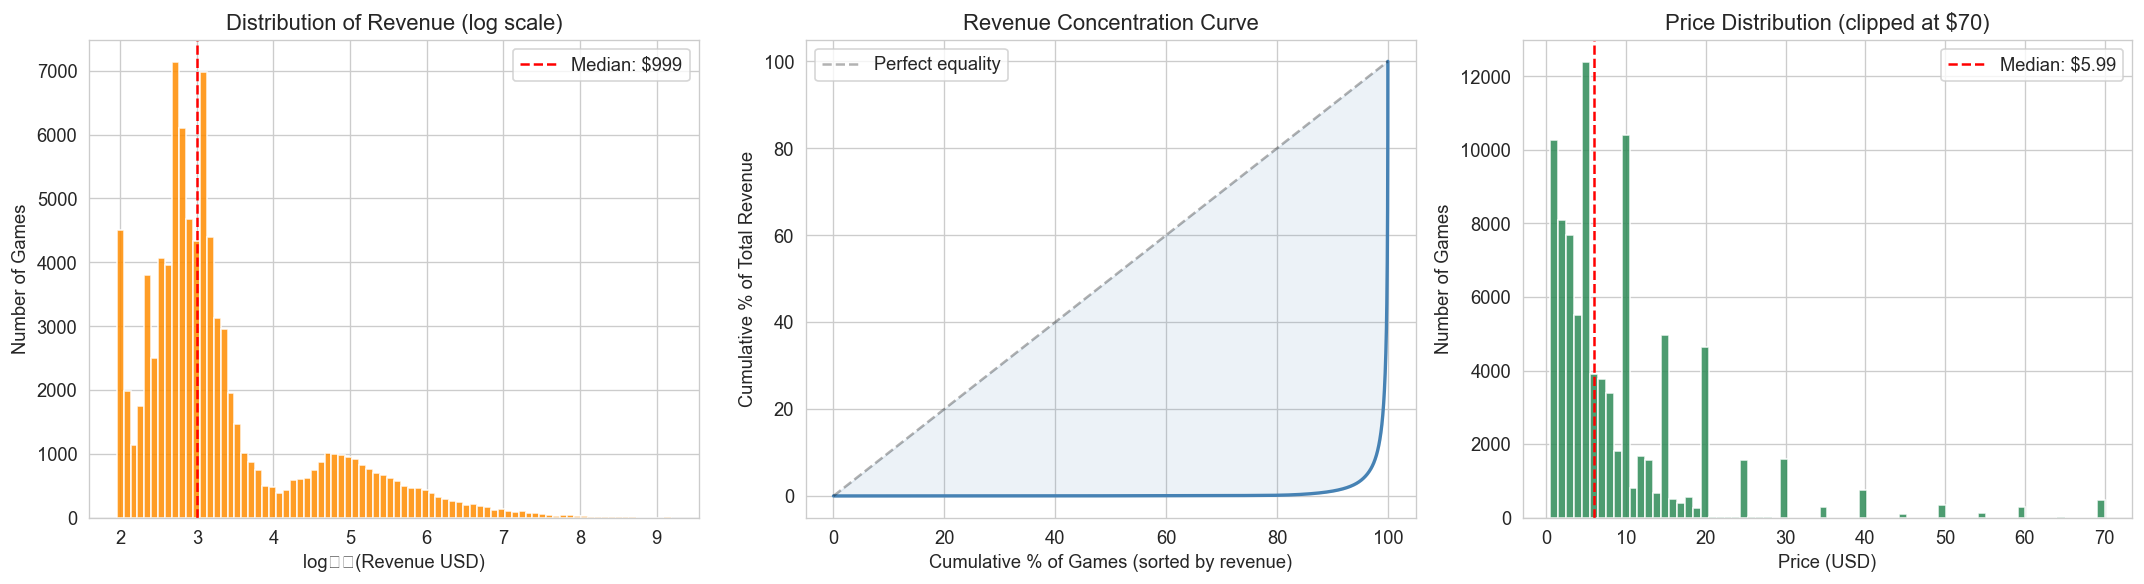

Games with zero revenue: 0 (0.0%)
Free games: 0 (0.0%)
Top 1% of games account for 82.5% of total revenue
Top 10% of games account for 98.9% of total revenue
Median revenue: $999
Mean revenue: $663,934
Total market revenue in dataset: $59.04 billion


In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue distribution (log)
rev_pos = df.loc[df['revenue'] > 0, 'revenue']
axes[0].hist(np.log10(rev_pos), bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('log₁₀(Revenue USD)')
axes[0].set_ylabel('Number of Games')
axes[0].set_title('Distribution of Revenue (log scale)')
axes[0].axvline(np.log10(rev_pos.median()), color='red', ls='--', label=f'Median: ${rev_pos.median():,.0f}')
axes[0].legend()

# Revenue cumulative share (Lorenz-style)
rev_sorted = df['revenue'].sort_values().values
rev_cum = np.cumsum(rev_sorted) / rev_sorted.sum()
axes[1].plot(np.linspace(0, 100, len(rev_cum)), rev_cum * 100, color='steelblue', linewidth=2)
axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect equality')
axes[1].set_xlabel('Cumulative % of Games (sorted by revenue)')
axes[1].set_ylabel('Cumulative % of Total Revenue')
axes[1].set_title('Revenue Concentration Curve')
axes[1].legend()
axes[1].fill_between(np.linspace(0, 100, len(rev_cum)), rev_cum * 100, np.linspace(0, 100, len(rev_cum)), alpha=0.1, color='steelblue')

# Price distribution
axes[2].hist(df['price_usd'].clip(upper=70), bins=70, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Price (USD)')
axes[2].set_ylabel('Number of Games')
axes[2].set_title('Price Distribution (clipped at $70)')
axes[2].axvline(df['price_usd'].median(), color='red', ls='--', label=f'Median: ${df["price_usd"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Games with zero revenue: {(df['revenue'] == 0).sum()} ({(df['revenue'] == 0).mean()*100:.1f}%)")
print(f"Free games: {(df['price_usd'] == 0).sum()} ({(df['price_usd'] == 0).mean()*100:.1f}%)")
print(f"Top 1% of games account for {df.nlargest(int(len(df)*0.01), 'revenue')['revenue'].sum() / df['revenue'].sum() * 100:.1f}% of total revenue")
print(f"Top 10% of games account for {df.nlargest(int(len(df)*0.10), 'revenue')['revenue'].sum() / df['revenue'].sum() * 100:.1f}% of total revenue")
print(f"Median revenue: ${df['revenue'].median():,.0f}")
print(f"Mean revenue: ${df['revenue'].mean():,.0f}")
print(f"Total market revenue in dataset: ${df['revenue'].sum() / 1e9:.2f} billion")

### Key Insight: Winner-Take-All Market

The Steam marketplace exhibits an extreme **power-law distribution** in revenue. Key observations:

- **The top 1% of games capture over 80% of total platform revenue.** This winner-take-all dynamic means the vast majority of titles generate negligible income.
- **The revenue concentration curve** (middle panel) shows a massive deviation from the equality line, confirming that the market is far more concentrated than typical consumer-goods industries.
- **The median revenue is dramatically lower than the mean**, reflecting the outsized influence of blockbuster titles on aggregate figures. The mean is pulled upward by a small number of mega-hits, while the typical game earns a fraction of that.
- **The price distribution** clusters heavily below $15, with a sharp spike at the free tier, indicating that most developers compete in a low-price environment.

**Implication for stakeholders:** Any market-entry strategy must account for the reality that *most games earn very little*. Success on Steam is the exception, not the norm, and requires deliberate differentiation across genre, pricing, polish, and marketing.

## 3. Temporal Trends: Market Growth & Saturation

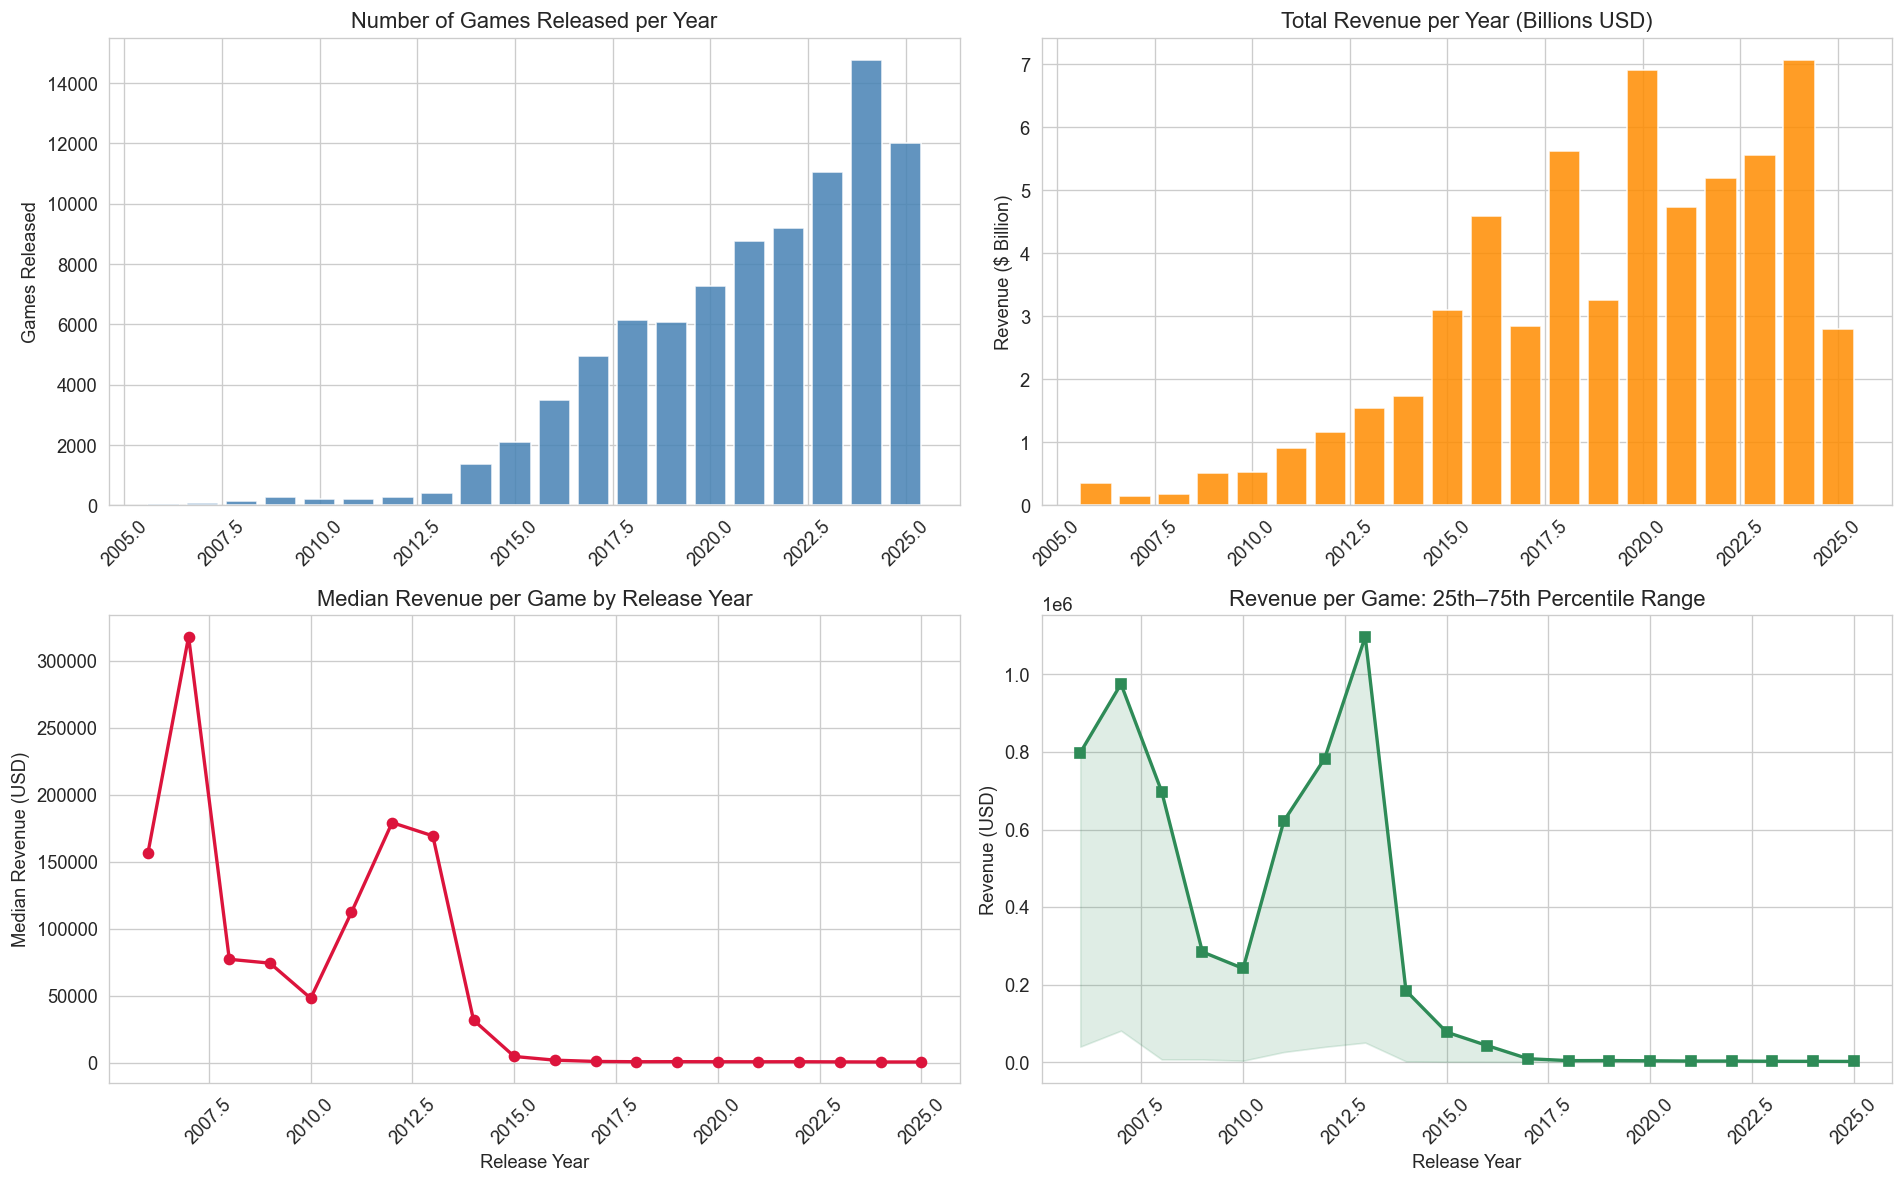

In [106]:
yearly = df.groupby('release_year').agg(
    n_games=('appid', 'count'),
    total_revenue=('revenue', 'sum'),
    median_revenue=('revenue', 'median'),
    mean_revenue=('revenue', 'mean'),
    p75_revenue=('revenue', lambda x: x.quantile(0.75)),
    p25_revenue=('revenue', lambda x: x.quantile(0.25))
).reset_index()
yearly = yearly[(yearly['release_year'] >= 2006) & (yearly['release_year'] <= 2025)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Number of games released per year
axes[0,0].bar(yearly['release_year'], yearly['n_games'], color='steelblue', alpha=0.85)
axes[0,0].set_title('Number of Games Released per Year')
axes[0,0].set_ylabel('Games Released')

# Total revenue per year
axes[0,1].bar(yearly['release_year'], yearly['total_revenue'] / 1e9, color='darkorange', alpha=0.85)
axes[0,1].set_title('Total Revenue per Year (Billions USD)')
axes[0,1].set_ylabel('Revenue ($ Billion)')

# Median revenue per year
axes[1,0].plot(yearly['release_year'], yearly['median_revenue'], 'o-', color='crimson', linewidth=2)
axes[1,0].set_title('Median Revenue per Game by Release Year')
axes[1,0].set_ylabel('Median Revenue (USD)')
axes[1,0].set_xlabel('Release Year')

# 75th percentile revenue per year
axes[1,1].plot(yearly['release_year'], yearly['p75_revenue'], 's-', color='seagreen', linewidth=2)
axes[1,1].fill_between(yearly['release_year'], yearly['p25_revenue'], yearly['p75_revenue'], alpha=0.15, color='seagreen')
axes[1,1].set_title('Revenue per Game: 25th–75th Percentile Range')
axes[1,1].set_ylabel('Revenue (USD)')
axes[1,1].set_xlabel('Release Year')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Key Insight: Supply Explosion, Revenue Dilution

The temporal analysis reveals a fundamental tension in the Steam ecosystem:

- **Game releases have grown approximately 10x since 2014**, with the platform seeing thousands of new titles each year. Steam's open-door policy via Steam Direct (2017) dramatically lowered the barrier to entry.
- **Aggregate platform revenue has grown**, reflecting Steam's expanding global user base and the success of tentpole releases.
- **However, median revenue per game has declined over the same period.** The typical game released in recent years earns substantially less than the typical game released in 2012–2015.
- **The interquartile range (bottom-right panel) shows tightening**: both the 25th and 75th percentile revenues have compressed downward, meaning even above-average games are earning less in real terms.

**Implication:** The market is growing in aggregate but fragmenting at the individual-title level. New entrants face a paradox: the platform is bigger than ever, but the odds of any single game capturing meaningful revenue are lower than ever. **Standing out requires deliberate strategy** in genre selection, pricing, feature polish, and launch timing.

## 4. Genre Analysis: What Sells?

In [107]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]
genre_names = [c.replace('genre_', '').replace('_', ' ').title() for c in genre_cols]

genre_stats = []
for col, name in zip(genre_cols, genre_names):
    subset = df[df[col] == 1]
    genre_stats.append({
        'Genre': name,
        'Count': len(subset),
        'Pct_of_Games': len(subset) / len(df) * 100,
        'Median_Revenue': subset['revenue'].median(),
        'Mean_Revenue': subset['revenue'].mean(),
        'P75_Revenue': subset['revenue'].quantile(0.75),
        'P90_Revenue': subset['revenue'].quantile(0.90),
        'Total_Revenue_B': subset['revenue'].sum() / 1e9,
        'Median_Price': subset['price_usd'].median()
    })

genre_df = pd.DataFrame(genre_stats).sort_values('Total_Revenue_B', ascending=False)
# Filter to main game genres (exclude tools/software)
game_genres = genre_df[genre_df['Count'] > 500].copy()
display(game_genres.round(1))

,Genre,Count,Pct_of_Games,Median_Revenue,Mean_Revenue,P75_Revenue,P90_Revenue,Total_Revenue_B,Median_Price
0,Action,36166,40.7,999.0,1056828.9,3716.1,186413.4,38.2,6.0
1,Adventure,35883,40.4,1098.9,795839.1,5997.0,189938.6,28.6,7.0
13,Rpg,16219,18.2,1447.1,1429855.5,39607.2,396733.4,23.2,8.0
10,Indie,63613,71.5,878.9,318973.6,2798.6,98457.6,20.3,5.0
14,Simulation,19058,21.4,1298.7,659497.7,22305.3,294752.8,12.6,7.0
16,Strategy,17603,19.8,1098.9,670723.4,8694.2,241558.2,11.8,7.0
4,Casual,39372,44.3,718.2,120652.8,1948.5,43648.6,4.8,5.0
11,Massively Multiplayer,1072,1.2,1398.3,4335255.8,21998.9,481499.3,4.6,7.0
6,Early Access,8615,9.7,1198.5,400621.7,2797.2,108826.7,3.5,9.0
15,Sports,3922,4.4,1198.6,393306.9,5596.2,125872.7,1.5,8.0


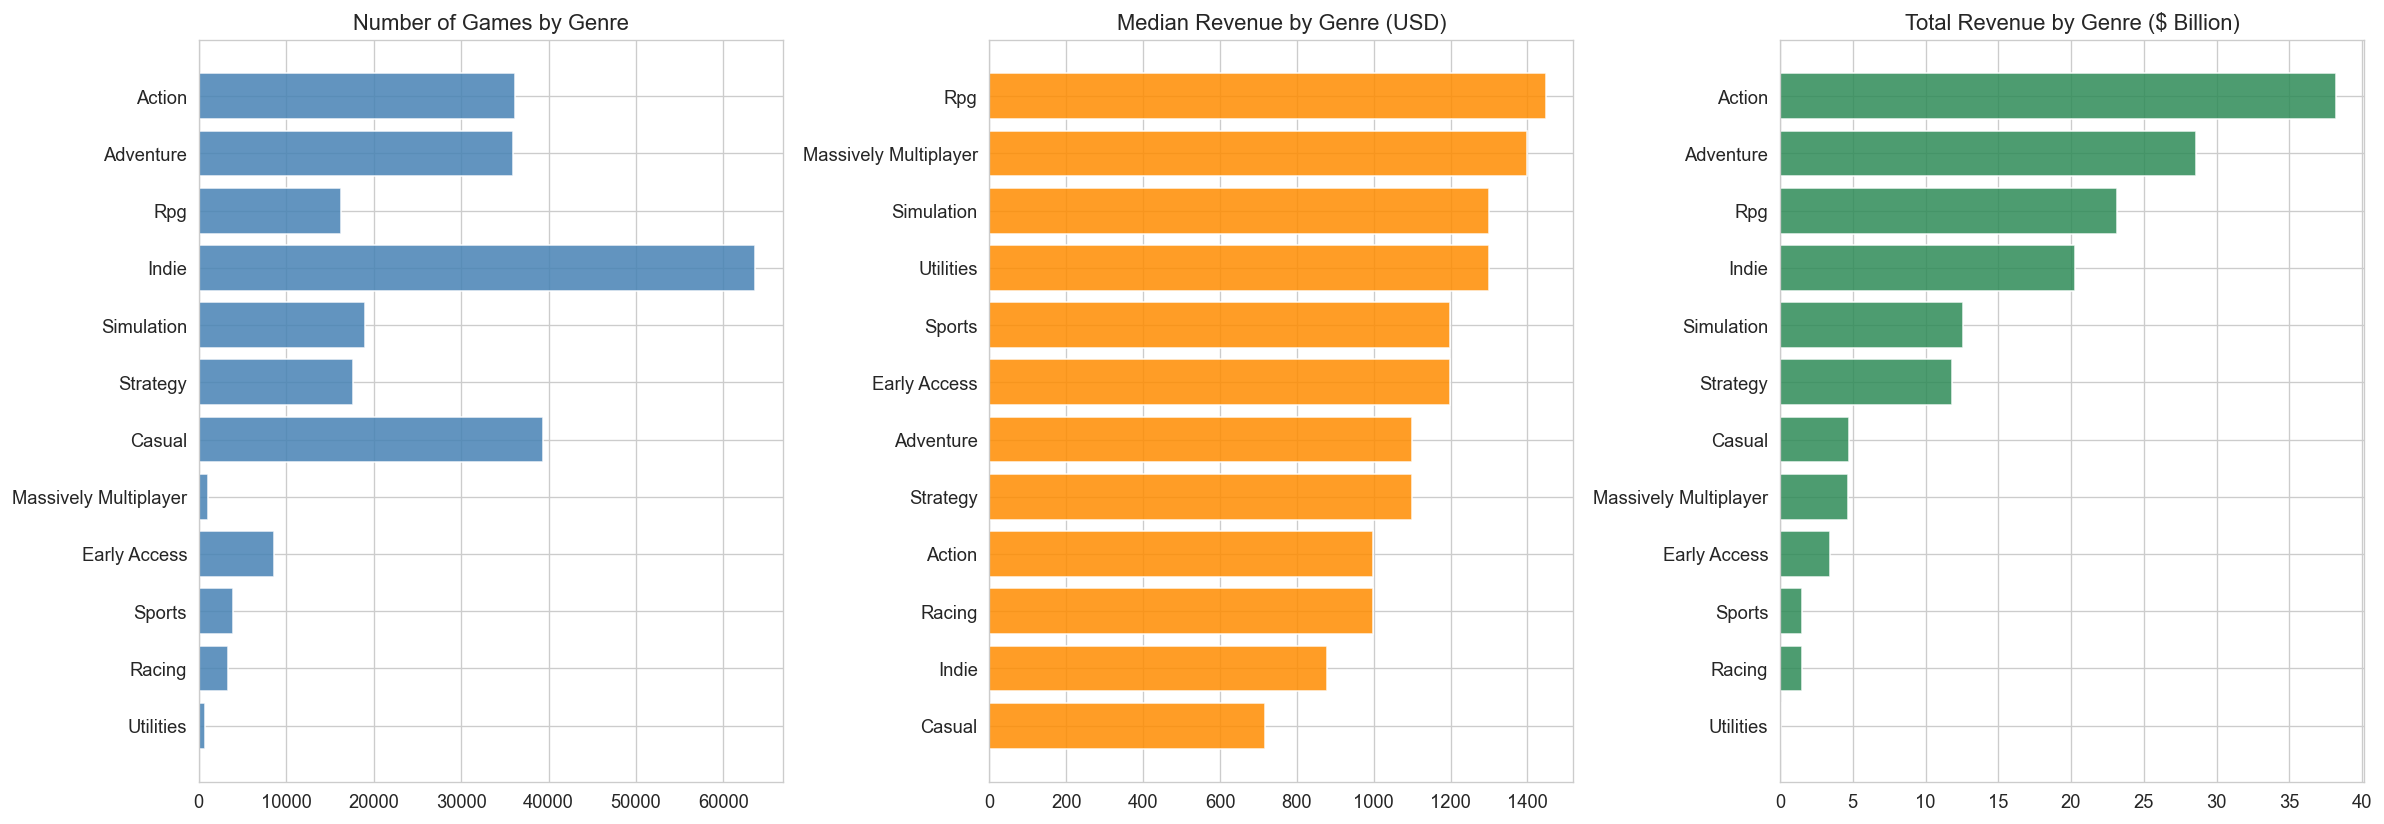

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

top_genres = game_genres.head(12)

# Count
axes[0].barh(top_genres['Genre'], top_genres['Count'], color='steelblue', alpha=0.85)
axes[0].set_title('Number of Games by Genre')
axes[0].invert_yaxis()

# Median revenue
top_by_median = game_genres.nlargest(12, 'Median_Revenue')
axes[1].barh(top_by_median['Genre'], top_by_median['Median_Revenue'], color='darkorange', alpha=0.85)
axes[1].set_title('Median Revenue by Genre (USD)')
axes[1].invert_yaxis()

# Total revenue
axes[2].barh(top_genres['Genre'], top_genres['Total_Revenue_B'], color='seagreen', alpha=0.85)
axes[2].set_title('Total Revenue by Genre ($ Billion)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### Key Insight: Indie Dominance in Volume, Not Revenue

The genre analysis reveals a striking disconnect between game volume and revenue performance:

- **Indie games are the most common genre (~71% of all titles)**, yet their median revenue is among the lowest. The sheer volume of indie releases means extreme competition within the category.
- **Action and RPG genres generate the highest median and total revenue.** Action games benefit from broad audience appeal and high replay value, while RPGs command premium pricing through deep content offerings.
- **Simulation and Strategy genres** occupy an interesting middle ground — moderate game counts but above-average median revenue, suggesting less saturated niches with healthier per-title economics.
- **The gap between "Count" and "Revenue" rankings** is instructive: genres with fewer titles but higher median revenue (e.g., Racing, Sports) may represent underserved segments.

**Implication for studios:** Genre choice is a strategic decision with significant revenue implications. For indie studios specifically, **blending genres** (e.g., Indie + RPG elements, or Indie + Simulation) can provide differentiation and tap into higher-revenue audience segments. Releasing a pure indie title into an oversaturated field without additional genre hooks reduces the probability of commercial viability.

## 5. Price Strategy: The Quality Signal Effect

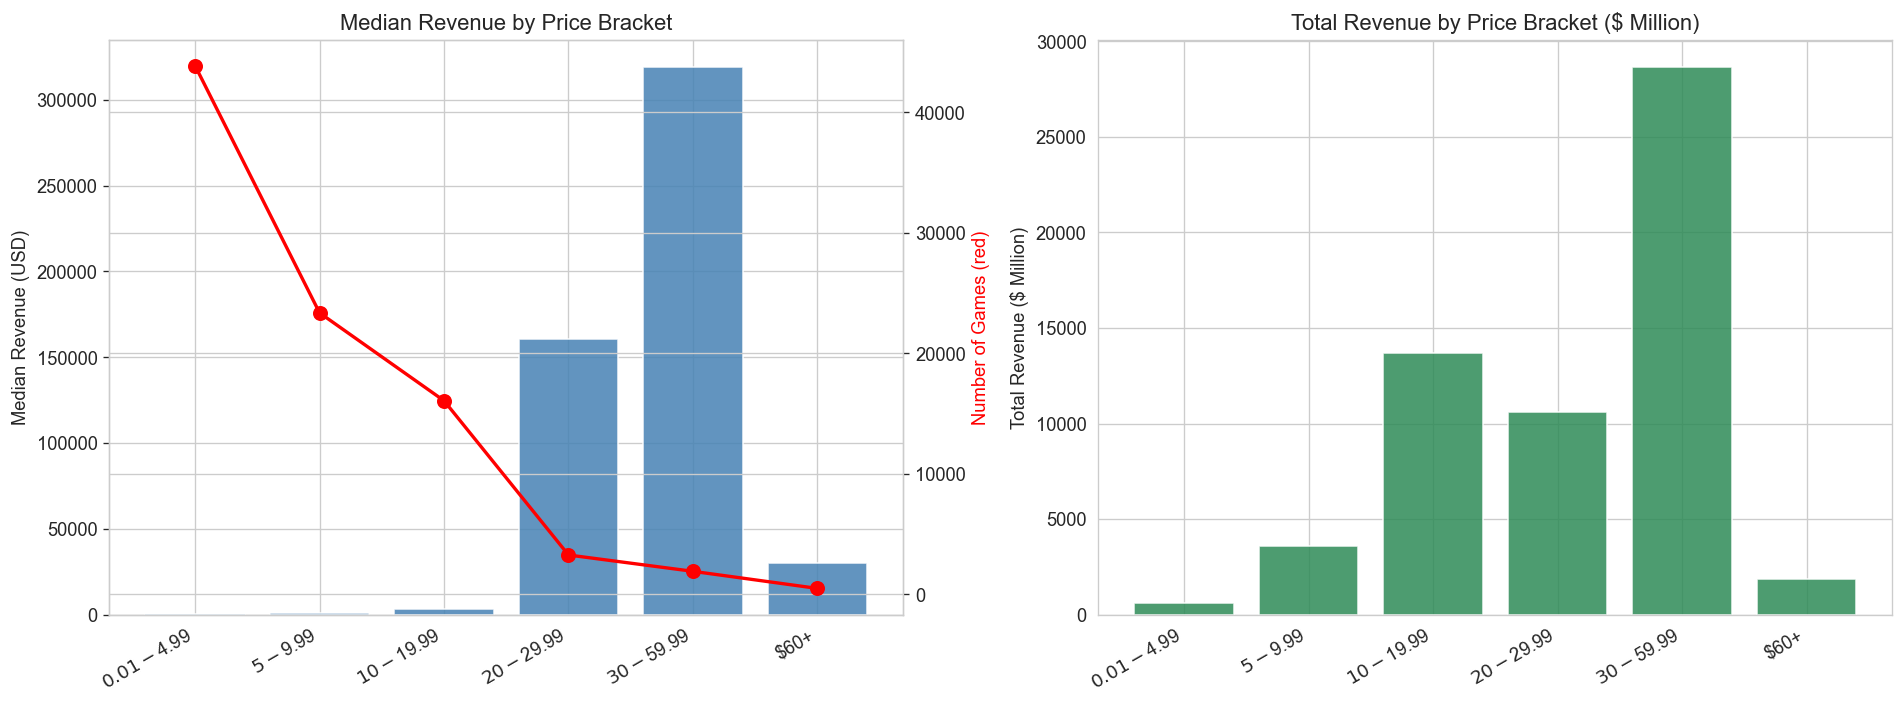

,price_bucket,n_games,median_revenue,p25_revenue,p75_revenue,mean_revenue,total_revenue_M
0,$0.01-$4.99,43853,439.0,219.0,649.0,13660.0,599.0
1,$5-$9.99,23350,1144.0,899.0,2877.0,153552.0,3585.0
2,$10-$19.99,16057,3398.0,1799.0,150401.0,852526.0,13689.0
3,$20-$29.99,3257,160436.0,3499.0,1178607.0,3259864.0,10617.0
4,$30-$59.99,1903,319120.0,5999.0,3516921.0,15061156.0,28661.0
5,$60+,485,29998.0,19999.0,45998.0,3875802.0,1880.0


In [109]:
# Create price buckets
bins = [0, 0.01, 4.99, 9.99, 19.99, 29.99, 59.99, 200]
labels = ['Free', '$0.01-$4.99', '$5-$9.99', '$10-$19.99', '$20-$29.99', '$30-$59.99', '$60+']
df['price_bucket'] = pd.cut(df['price_usd'], bins=bins, labels=labels, include_lowest=True)

price_stats = df.groupby('price_bucket', observed=True).agg(
    n_games=('appid', 'count'),
    median_revenue=('revenue', 'median'),
    p25_revenue=('revenue', lambda x: x.quantile(0.25)),
    p75_revenue=('revenue', lambda x: x.quantile(0.75)),
    mean_revenue=('revenue', 'mean'),
    total_revenue_M=('revenue', lambda x: x.sum() / 1e6)
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = range(len(price_stats))
axes[0].bar(x, price_stats['median_revenue'], color='steelblue', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(price_stats['price_bucket'], rotation=30, ha='right')
axes[0].set_title('Median Revenue by Price Bracket')
axes[0].set_ylabel('Median Revenue (USD)')

# Add game count on secondary axis
ax2 = axes[0].twinx()
ax2.plot(x, price_stats['n_games'], 'ro-', linewidth=2, markersize=8)
ax2.set_ylabel('Number of Games (red)', color='red')

axes[1].bar(x, price_stats['total_revenue_M'], color='seagreen', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(price_stats['price_bucket'], rotation=30, ha='right')
axes[1].set_title('Total Revenue by Price Bracket ($ Million)')
axes[1].set_ylabel('Total Revenue ($ Million)')

plt.tight_layout()
plt.show()

display(price_stats.round(0))

### Key Insight: Price as a Quality Signal

The relationship between price point and revenue performance reveals important strategic dynamics:

- **Higher-priced games have dramatically higher median revenue.** Games priced at $20–$30 earn multiples more than those in the $1–$5 bracket. This is not a simple causal relationship — charging more does not automatically generate more revenue.
- **Price acts as a proxy for production quality and publisher confidence.** Studios that invest in polished content, professional art, QA, and marketing tend to price higher because they can justify the price point. The price itself then signals quality to potential buyers.
- **The "Free" and "$0.01–$4.99" tiers show the lowest median revenue**, dominated by low-effort titles, asset flips, and hobbyist projects that dilute the category.
- **The $10–$19.99 bracket represents a strategic sweet spot**: it is the most populated paid tier (high competition, but validated demand) and achieves a substantial jump in median revenue over cheaper tiers.
- **The right panel (total revenue by bracket)** shows where the aggregate dollars flow — useful for understanding which tiers drive platform-wide economics.

**Implication for indie studios:** Avoid the temptation to underprice. Pricing at $10–$20 signals seriousness and quality to both the Steam recommendation algorithm and prospective buyers. A $3 game, regardless of its actual quality, will be perceived as and algorithmically treated as low-value content.

## 6. Game Features (Categories) & Revenue

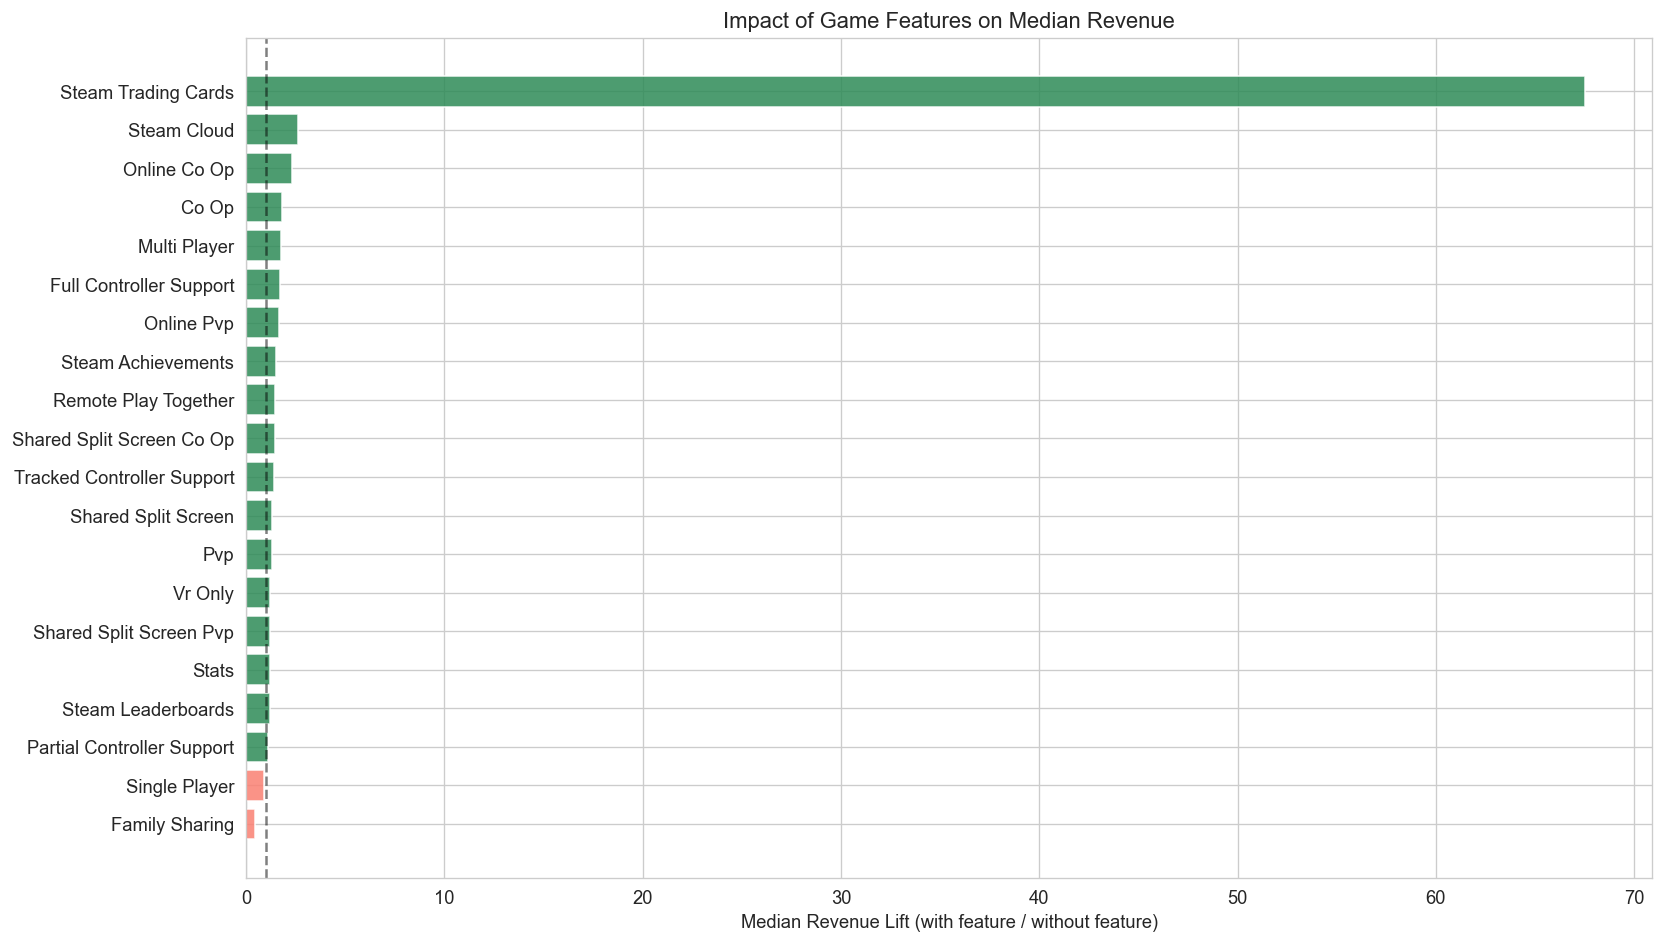


Top features by revenue lift:


,Feature,Games_With,Median_Revenue_With,Median_Revenue_Without,Lift,P75_Revenue_With
17,Steam Trading Cards,10073,59360.4,878.9,67.5,403380.9
15,Steam Cloud,25011,2078.7,798.0,2.6,111855.3
4,Online Co Op,4460,2296.6,988.9,2.3,234777.4
0,Co Op,7921,1746.5,958.8,1.8,95604.3
3,Multi Player,14214,1598.4,908.7,1.8,63734.8
2,Full Controller Support,20471,1498.5,878.9,1.7,58422.0
5,Online Pvp,5426,1648.9,988.9,1.7,95568.3
14,Steam Achievements,45313,1208.9,799.0,1.5,33832.2
8,Remote Play Together,6407,1428.9,988.9,1.4,30687.3
10,Shared Split Screen Co Op,3564,1438.8,998.0,1.4,16354.7


In [110]:
cat_cols = [c for c in df.columns if c.startswith('cat_')]
cat_names = [c.replace('cat_', '').replace('_', ' ').title() for c in cat_cols]

cat_stats = []
for col, name in zip(cat_cols, cat_names):
    with_feat = df[df[col] == 1]['revenue']
    without_feat = df[df[col] == 0]['revenue']
    cat_stats.append({
        'Feature': name,
        'Games_With': len(with_feat),
        'Median_Revenue_With': with_feat.median(),
        'Median_Revenue_Without': without_feat.median(),
        'Lift': with_feat.median() / max(without_feat.median(), 1),
        'P75_Revenue_With': with_feat.quantile(0.75)
    })

cat_df = pd.DataFrame(cat_stats).sort_values('Lift', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
cat_plot = cat_df[cat_df['Games_With'] > 200].sort_values('Lift')
colors = ['seagreen' if x > 1 else 'salmon' for x in cat_plot['Lift']]
ax.barh(cat_plot['Feature'], cat_plot['Lift'], color=colors, alpha=0.85)
ax.axvline(1, color='black', ls='--', alpha=0.5)
ax.set_xlabel('Median Revenue Lift (with feature / without feature)')
ax.set_title('Impact of Game Features on Median Revenue')
plt.tight_layout()
plt.show()

print('\nTop features by revenue lift:')
display(cat_df[cat_df['Games_With'] > 200].head(10).round(1))

### Key Insight: Low-Cost Feature Wins

Certain Steam platform features show a strong positive association with higher revenue, and many of them are **relatively low-cost to implement**:

- **Steam Trading Cards, Steam Cloud Save, Achievements, and Full Controller Support** stand out as features with the highest median revenue lift. Games that include these features earn multiples more than those that do not.
- These features serve a dual purpose: (1) they directly improve the player experience (cloud saves prevent frustration; achievements extend engagement), and (2) they **signal polish and professionalism** to the Steam algorithm and to prospective buyers browsing the store.
- **Multiplayer features** (Co-op, Online PvP) also show positive lift, reflecting the higher engagement and word-of-mouth potential of social gaming experiences.
- Features below the 1.0 lift line (shown in red) are either neutral or associated with lower-revenue titles — this does not mean the features *cause* lower revenue, but rather that they are more prevalent among lower-quality titles.

**Implication:** For studios operating on limited budgets, **prioritizing these high-lift, low-cost features** provides outsized return on investment. Adding achievements, cloud save, and trading card support should be considered near-mandatory for any commercial release aiming for visibility on the Steam platform.

## 7. Indie / Self-Published Analysis

In [111]:
# Define "indie" as self-published + tagged as indie genre
df['is_indie'] = ((df['genre_indie'] == 1) & (df['is_self_published'] == 1)).astype(int)
df['is_small_studio'] = (df['dev_game_count'] <= 5).astype(int)

segments = {
    'All Games': df,
    'Indie & Self-Published': df[df['is_indie'] == 1],
    'Small Studio (≤5 games)': df[df['is_small_studio'] == 1],
    'Small Indie Studio': df[(df['is_indie'] == 1) & (df['is_small_studio'] == 1)],
    'Established (>20 games)': df[df['dev_game_count'] > 20]
}

seg_stats = []
for name, subset in segments.items():
    seg_stats.append({
        'Segment': name,
        'N': len(subset),
        'Median_Revenue': subset['revenue'].median(),
        'Mean_Revenue': subset['revenue'].mean(),
        'P75_Revenue': subset['revenue'].quantile(0.75),
        'P90_Revenue': subset['revenue'].quantile(0.90),
        'Median_Price': subset['price_usd'].median(),
        'Total_Revenue_B': subset['revenue'].sum() / 1e9,
        'Pct_Free': (subset['price_usd'] == 0).mean() * 100
    })

seg_df = pd.DataFrame(seg_stats)
display(seg_df.round(1))

,Segment,N,Median_Revenue,Mean_Revenue,P75_Revenue,P90_Revenue,Median_Price,Total_Revenue_B,Pct_Free
0,All Games,88917,999.0,663934.0,3704.7,146651.1,6.0,59.0,0.0
1,Indie & Self-Published,49578,798.4,283625.6,2198.9,61763.6,5.0,14.1,0.0
2,Small Studio (≤5 games),59274,878.9,260042.7,2198.9,71394.1,5.0,15.4,0.0
3,Small Indie Studio,35039,748.5,151525.6,1737.1,30461.3,5.0,5.3,0.0
4,Established (>20 games),12186,1225.9,1933381.1,31342.7,666799.2,7.0,23.6,0.0


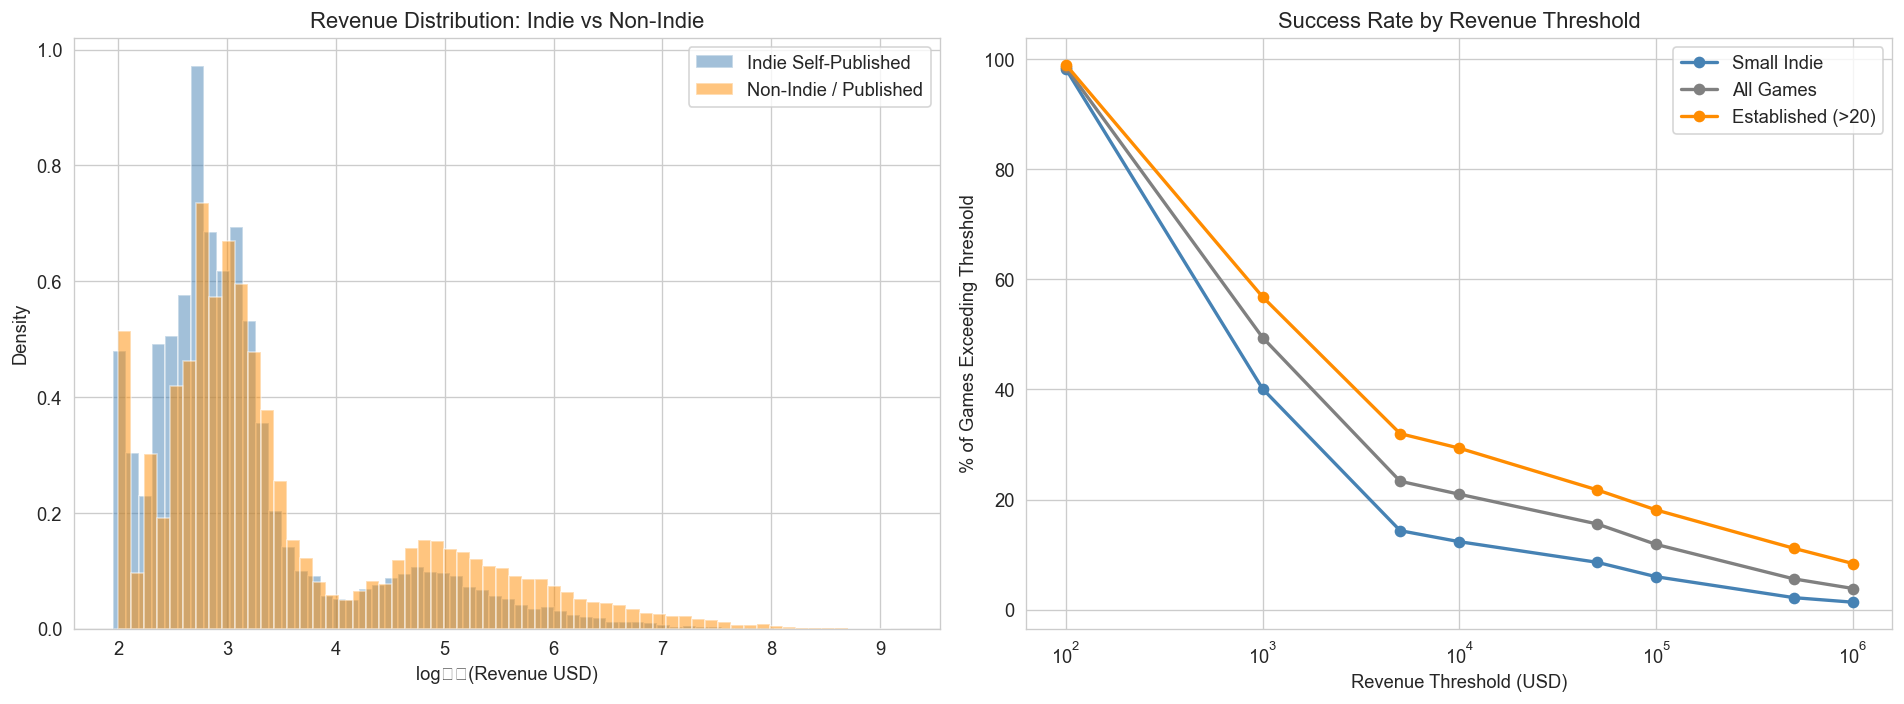

In [112]:
# Revenue distribution comparison: Indie vs Non-Indie
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, color, mask in [('Indie Self-Published', 'steelblue', df['is_indie']==1), 
                            ('Non-Indie / Published', 'darkorange', df['is_indie']==0)]:
    rev = df.loc[mask & (df['revenue'] > 0), 'revenue']
    axes[0].hist(np.log10(rev), bins=60, alpha=0.5, label=label, color=color, density=True)

axes[0].set_xlabel('log₁₀(Revenue USD)')
axes[0].set_ylabel('Density')
axes[0].set_title('Revenue Distribution: Indie vs Non-Indie')
axes[0].legend()

# Success rate by segment (revenue > different thresholds)
thresholds = [100, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
for name, subset, color in [('Small Indie', df[(df['is_indie']==1) & (df['is_small_studio']==1)], 'steelblue'),
                             ('All Games', df, 'gray'),
                             ('Established (>20)', df[df['dev_game_count']>20], 'darkorange')]:
    rates = [(subset['revenue'] >= t).mean() * 100 for t in thresholds]
    axes[1].plot(thresholds, rates, 'o-', label=name, color=color, linewidth=2)

axes[1].set_xscale('log')
axes[1].set_xlabel('Revenue Threshold (USD)')
axes[1].set_ylabel('% of Games Exceeding Threshold')
axes[1].set_title('Success Rate by Revenue Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

### Key Insight: The Indie Challenge

The segment comparison quantifies the structural disadvantages facing indie developers — and the opportunities that remain:

- **Small indie studios have significantly lower median revenue** than established publishers, reflecting differences in marketing budgets, brand recognition, Steam algorithm favorability, and production resources.
- **The revenue distribution (left panel)** shows that indie titles are shifted leftward (toward lower revenue), but the distributions overlap substantially — confirming that high-performing indie titles absolutely exist.
- **The success rate curve (right panel)** is particularly revealing: at every revenue threshold, established studios outperform small indie developers. However, the **gap narrows at higher thresholds**, meaning that among the subset of games that achieve breakout status, the indie-vs-established distinction matters less.
- **Self-published indie studios have a higher percentage of free games**, which mechanically drags down their revenue metrics. Controlling for paid-only titles would narrow the gap further.

**Implication:** While the median indie outcome is discouraging, the **tail outcomes are encouraging**. Indie studios that execute well on controllable factors — genre selection, pricing strategy, feature polish, localization — can and do reach the same revenue tiers as published titles. The key is maximizing these controllable levers (explored further in the modeling notebook).

## 8. Platform & Localization

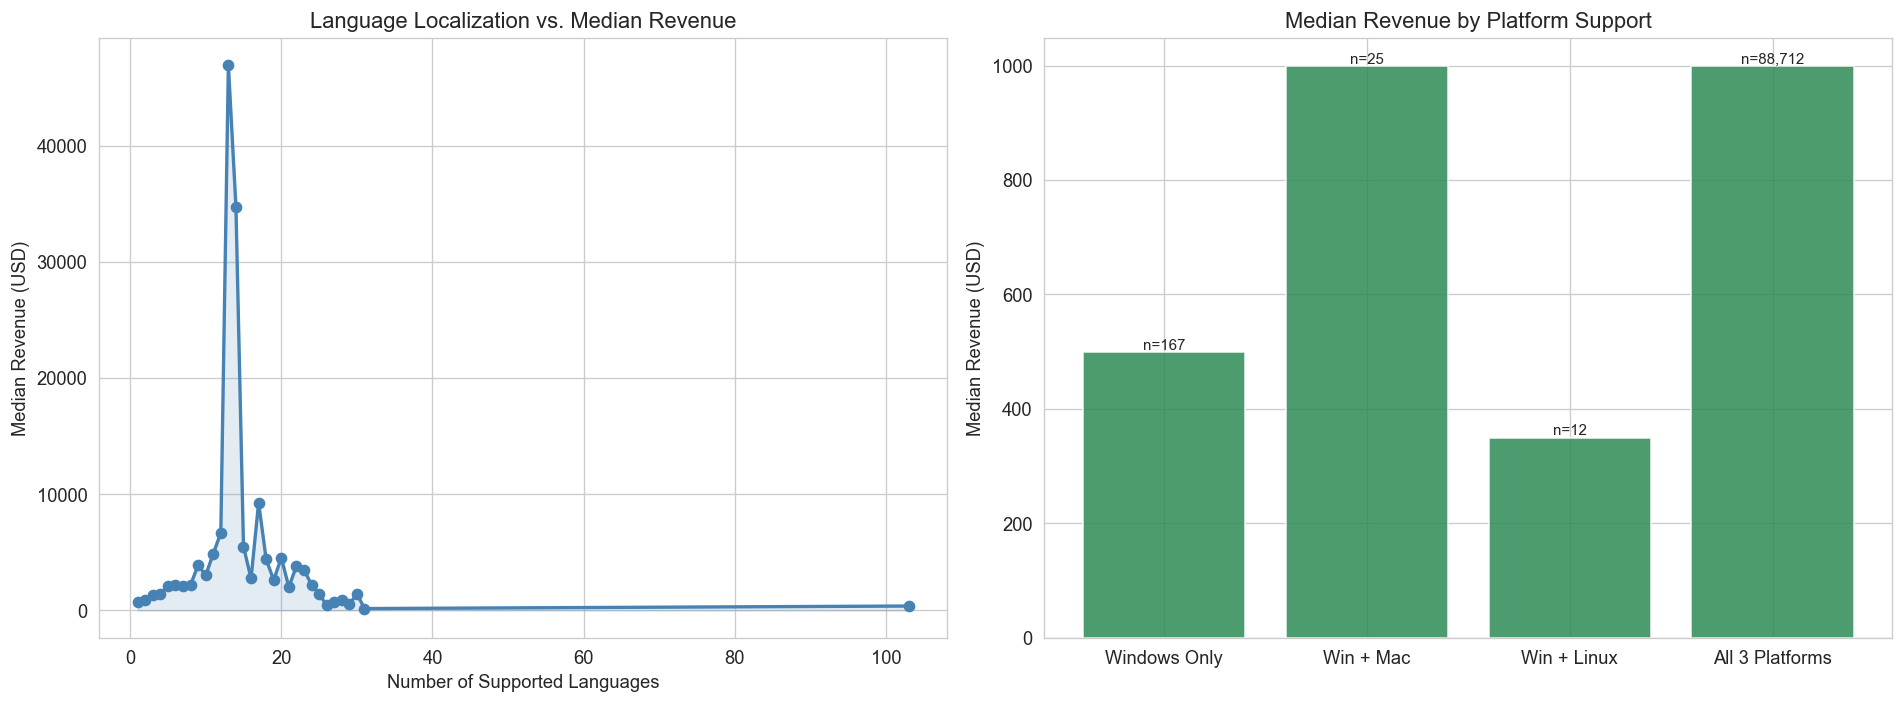

In [113]:
# Language count vs revenue
lang_stats = df.groupby('supported_languages').agg(
    n_games=('appid', 'count'),
    median_revenue=('revenue', 'median'),
    p75_revenue=('revenue', lambda x: x.quantile(0.75))
).reset_index()
lang_stats = lang_stats[lang_stats['n_games'] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(lang_stats['supported_languages'], lang_stats['median_revenue'], 'o-', color='steelblue', linewidth=2)
axes[0].fill_between(lang_stats['supported_languages'], 0, lang_stats['median_revenue'], alpha=0.15, color='steelblue')
axes[0].set_xlabel('Number of Supported Languages')
axes[0].set_ylabel('Median Revenue (USD)')
axes[0].set_title('Language Localization vs. Median Revenue')

# Platform support
platform_combos = {
    'Windows Only': (df['supports_windows']==True) & (df['supports_mac']==False) & (df['supports_linux']==False),
    'Win + Mac': (df['supports_windows']==True) & (df['supports_mac']==True) & (df['supports_linux']==False),
    'Win + Linux': (df['supports_windows']==True) & (df['supports_mac']==False) & (df['supports_linux']==True),
    'All 3 Platforms': (df['supports_windows']==True) & (df['supports_mac']==True) & (df['supports_linux']==True),
}

plat_data = []
for name, mask in platform_combos.items():
    subset = df[mask]
    plat_data.append({'Platform': name, 'N': len(subset), 'Median_Revenue': subset['revenue'].median()})
plat_df = pd.DataFrame(plat_data)

axes[1].bar(plat_df['Platform'], plat_df['Median_Revenue'], color='seagreen', alpha=0.85)
axes[1].set_title('Median Revenue by Platform Support')
axes[1].set_ylabel('Median Revenue (USD)')
# Add count annotations
for i, row in plat_df.iterrows():
    axes[1].annotate(f'n={row["N"]:,}', (i, row['Median_Revenue']), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Key Insight: Localization Has Diminishing Returns

Language support and platform availability both correlate with higher revenue, but with important nuances:

- **Moving from 1 to 3–5 supported languages provides the steepest revenue lift.** This initial localization effort captures the largest incremental audiences (Chinese, Russian, and Spanish-speaking players represent massive Steam user bases).
- **Beyond approximately 13 languages, the median revenue curve flattens.** Additional localizations reach progressively smaller audiences and yield diminishing incremental revenue.
- **Priority languages for resource-constrained studios:** English (baseline), Simplified Chinese, Russian, Spanish, and German — these correspond to the top 5 Steam markets by active users.
- **Multi-platform support (right panel)** shows a clear step-up in median revenue for games supporting all three major platforms (Windows, Mac, Linux). Games supporting all 3 platforms earn meaningfully more, though this likely reflects studio capability and commitment rather than Mac/Linux revenue alone.

**Implication:** Localization into 3–5 key languages offers the best ROI for most studios. Multi-platform support serves as both a direct revenue driver (broader addressable market) and an indirect quality signal. Studios should prioritize the top 5 languages before considering broader localization.

## 9. Correlation Heatmap: Feature Relationships

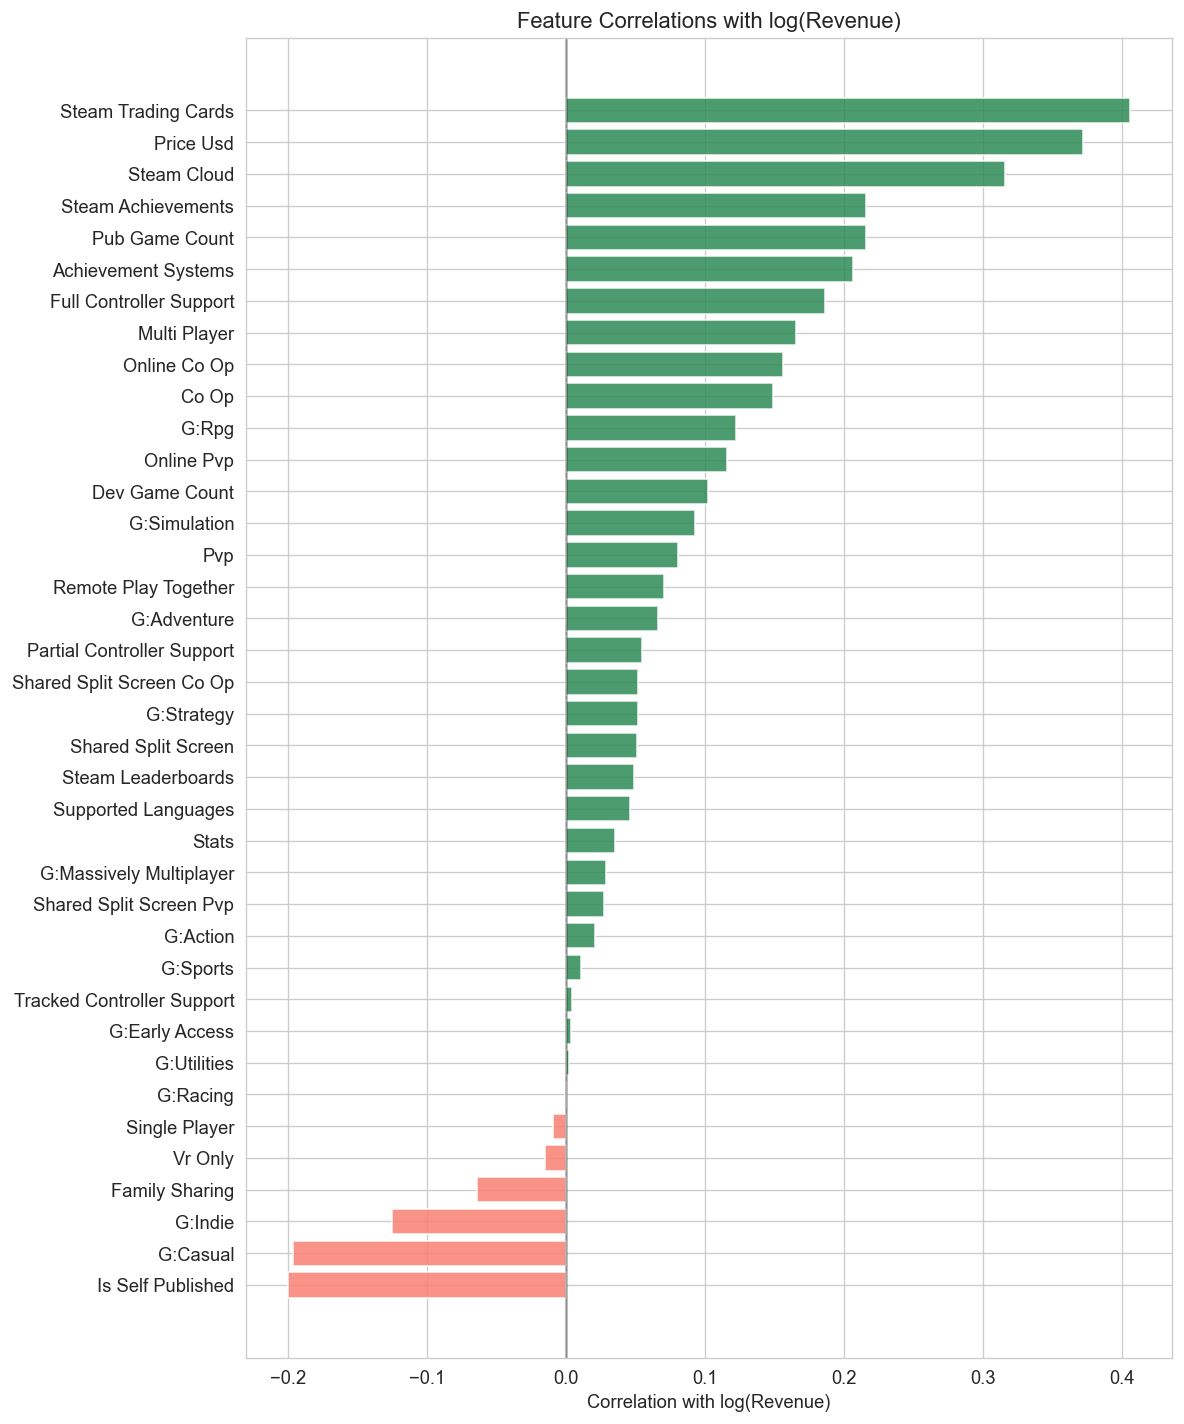

In [114]:
# Correlation of key features with log revenue
df['log_revenue'] = np.log1p(df['revenue'])

feature_cols = ['price_usd', 'supported_languages', 'dev_game_count', 'pub_game_count', 
                'is_self_published', 'achievement_systems'] + \
               [c for c in cat_cols if df[c].sum() > 500] + \
               [c for c in genre_cols if df[c].sum() > 500]

corr_with_revenue = df[feature_cols + ['log_revenue']].corr()['log_revenue'].drop('log_revenue').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['seagreen' if x > 0 else 'salmon' for x in corr_with_revenue]
ax.barh(range(len(corr_with_revenue)), corr_with_revenue.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(corr_with_revenue)))
ax.set_yticklabels([c.replace('cat_', '').replace('genre_', 'G:').replace('_', ' ').title() for c in corr_with_revenue.index])
ax.set_xlabel('Correlation with log(Revenue)')
ax.set_title('Feature Correlations with log(Revenue)')
ax.axvline(0, color='black', ls='-', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Top Performing Games — What Do They Have in Common?

In [115]:
top100 = df.nlargest(100, 'revenue')
print('=== Profile of Top 100 Highest-Revenue Games ===')
print(f"Median price: ${top100['price_usd'].median():.2f}  (All games: ${df['price_usd'].median():.2f})")
print(f"Median languages: {top100['supported_languages'].median():.0f}  (All games: {df['supported_languages'].median():.0f})")
print(f"Self-published: {top100['is_self_published'].mean()*100:.1f}%  (All games: {df['is_self_published'].mean()*100:.1f}%)")
print(f"Has achievements: {top100['achievement_systems'].mean()*100:.1f}%  (All: {df['achievement_systems'].mean()*100:.1f}%)")
print(f"Indie genre: {top100['genre_indie'].mean()*100:.1f}%  (All: {df['genre_indie'].mean()*100:.1f}%)")
print(f"\nTotal revenue of top 100: ${top100['revenue'].sum()/1e9:.2f}B ({top100['revenue'].sum()/df['revenue'].sum()*100:.1f}% of all revenue)")
print(f"\nTop genre breakdown:")
for col in genre_cols:
    pct = top100[col].mean() * 100
    if pct > 20:
        print(f"  {col.replace('genre_', '').title()}: {pct:.0f}%")

print(f"\nTop category breakdown:")
for col in cat_cols:
    pct = top100[col].mean() * 100
    if pct > 30:
        print(f"  {col.replace('cat_', '').replace('_', ' ').title()}: {pct:.0f}%")

=== Profile of Top 100 Highest-Revenue Games ===
Median price: $39.99  (All games: $5.99)
Median languages: 14  (All games: 1)
Self-published: 61.0%  (All games: 74.3%)
Has achievements: 92.0%  (All: 57.9%)
Indie genre: 32.0%  (All: 71.5%)

Total revenue of top 100: $27.59B (46.7% of all revenue)

Top genre breakdown:
  Action: 71%
  Adventure: 50%
  Indie: 32%
  Rpg: 39%
  Strategy: 22%

Top category breakdown:
  Co Op: 54%
  Family Sharing: 81%
  Full Controller Support: 56%
  Multi Player: 66%
  Online Co Op: 46%
  Online Pvp: 34%
  Pvp: 34%
  Single Player: 89%
  Steam Achievements: 90%
  Steam Cloud: 70%
  Steam Trading Cards: 70%


In [116]:
# Show top 20 games by revenue
print('=== Top 20 Games by Revenue ===')
display(top100[['name', 'price_usd', 'estimated_sales', 'revenue', 'genre_indie', 
                 'is_self_published', 'supported_languages', 'release_year']].head(20))

=== Top 20 Games by Revenue ===


,name,price_usd,estimated_sales,revenue,genre_indie,is_self_published,supported_languages,release_year
0,Black Myth: Wukong,59.99,25659840,1.539334e+09,0,1,14,2024
1,Cyberpunk 2077,59.99,23601720,1.415867e+09,0,1,19,2020
2,ELDEN RING,59.99,23526240,1.411339e+09,0,1,15,2022
3,Rust,39.99,31301130,1.251732e+09,1,1,25,2018
4,Baldur's Gate 3,59.99,20625990,1.237353e+09,0,1,15,2023
5,The Witcher 3: Wild Hunt,39.99,23542050,9.414466e+08,0,1,17,2015
6,HELLDIVERS™ 2,39.99,22796100,9.116160e+08,0,0,14,2024
7,DayZ,49.99,10883250,5.440537e+08,0,1,12,2018
8,No Man's Sky,59.99,8206050,4.922809e+08,0,1,14,2016
9,DARK SOULS™ III,59.99,7967430,4.779661e+08,0,1,12,2016


### Key Insight: The Anatomy of a Hit

Profiling the top 100 highest-revenue games on Steam reveals a consistent pattern of attributes:

- **Genre:** Action and RPG genres dominate, often in combination. Adventure is also well-represented. These genres have broad appeal and support premium pricing.
- **Pricing:** The median price of top-100 games is significantly higher than the platform median, reinforcing the price-as-quality-signal finding from Section 5.
- **Localization:** Top games support far more languages than the average title, reflecting both the studios' investment in global reach and the compounding effect of accessible content.
- **Features:** Achievements, cloud save, and multiplayer components are near-universal among top performers — consistent with Section 6 findings.
- **Indie representation:** A notable share of top-100 games carry the indie genre tag or are self-published, demonstrating that **small studios can and do compete at the highest revenue tiers**. However, these tend to be the standout exceptions rather than the norm.
- **Revenue concentration:** The top 100 games alone account for a disproportionate share of total platform revenue, further underscoring the winner-take-all market structure.

**Implication:** There is no single formula for a hit, but the **common denominators are clear**: premium pricing justified by quality, broad accessibility (languages, platforms, features), and strong genre positioning. Studios should benchmark against these attributes when evaluating their own titles' commercial readiness.

## Summary of EDA Findings

The following table summarizes the key findings from this exploratory analysis, along with their strategic implications:

| # | Finding | Evidence | Implication |
|---|---------|----------|-------------|
| 1 | **Revenue is extremely concentrated** — top 1% of games earn >80% of total platform revenue | Revenue distribution & concentration curve (Section 2) | Success requires deliberate differentiation; simply shipping a game is insufficient |
| 2 | **Game releases grew ~10x since 2014**, but median per-game revenue has declined | Temporal trends (Section 3) | Increased competition demands strategic genre, pricing, and feature choices |
| 3 | **Higher price correlates with higher revenue** — price acts as a quality signal | Price bracket analysis (Section 5) | Don't underprice — the $10–$20 range is the sweet spot for indie titles |
| 4 | **Trading Cards, Cloud Save, Achievements** are associated with significant revenue lift | Feature lift analysis (Section 6) | Low-cost, high-impact polish signals that should be near-mandatory |
| 5 | **3–5 languages provide the biggest localization ROI** | Localization curve (Section 8) | Prioritize EN, ZH, RU, ES, DE before broader localization |
| 6 | **Action/RPG genres generate the highest revenue** both per-title and in aggregate | Genre analysis (Section 4) | Genre choice is strategic — genre blending can unlock higher revenue tiers |
| 7 | **Indie studios face structural disadvantages** but breakout hits are achievable | Segment comparison (Section 7) | Controllable factors (features, pricing, localization) can close the gap |
| 8 | **Top-100 games share a consistent profile**: premium price, many languages, key features, Action/RPG genre | Top games profiling (Section 10) | Use this profile as a benchmark for commercial readiness |


# Part 4: Feature Selection

Since the goal of our project is to provide actionable, interpretable strategies for small game companies, we prioritize feature selection methods that preserve the original meaning of each feature, rather than dimensionality-reduction techniques like PCA which create abstract components.

We apply a three-step feature selection pipeline:

1. **Near-zero-variance filtering:** Remove features where a single value dominates >= 98% of the data, as they carry almost no discriminative information.
2. **Correlation-based filtering:** Visualize the feature correlation heatmap and remove one feature from each highly correlated pair (|r| > 0.85) to reduce multicollinearity, keeping the one more correlated with the target.
3. **Lasso (L1 regularization):** Use `LassoCV` with cross-validation to shrink feature coefficients. Features with |coefficient| < 0.01 are dropped as negligible contributors, yielding a sparse, interpretable feature set.

**Target variable:** `revenue` is log-transformed via `log1p` to handle extreme right-skewness.

**Excluded columns:** `appid`, `name`, `developer_name`, `publisher_name` (identifiers/text), and `estimated_sales` (data leakage since `revenue = price * estimated_sales`).

## 4.1 Near-zero-variance

We first prepare the feature matrix `X` and the target variable `y`. Identifier columns and `estimated_sales` are excluded to prevent data leakage. Boolean columns are cast to integers.

For the near-zero-variance step, rather than only removing features with exactly zero variance, we compute the **dominant value ratio** — the proportion of the most frequent value in each column. If a single value accounts for >= 98% of all observations, the feature provides almost no discriminative power and is dropped. For example, `supports_windows` is True for nearly all games and would be removed by this filter.

In [122]:
# ── Step 0: Prepare features and target ────────────────────────────────────────
# Exclude identifiers, text columns, and estimated_sales (data leakage)
main_df = pd.read_csv('./main_df.csv')

exclude_cols = {"appid", "name", "developer_name", "publisher_name",
                "estimated_sales", "revenue"}
feature_cols = [c for c in main_df.columns if c not in exclude_cols]

X = main_df[feature_cols].copy()
# Convert boolean columns (supports_windows/mac/linux) to int for consistency
for col in X.select_dtypes(include="bool").columns:
    X[col] = X[col].astype(int)

# Log-transform revenue to handle extreme right-skewness
y = np.log1p(main_df["revenue"])

print(f"Initial feature count: {X.shape[1]}")

# ── Step 1: Near-zero-variance filtering ──────────────────────────────────────
# If >= 98% of values are the same, the feature has almost no discriminative power
DOMINANCE_THRESHOLD = 0.98

low_var_cols = []
for col in X.columns:
    # Compute the proportion of the most frequent value
    top_freq = X[col].value_counts(normalize=True).iloc[0]
    if top_freq >= DOMINANCE_THRESHOLD:
        low_var_cols.append((col, top_freq))

if low_var_cols:
    drop_names = [c for c, _ in low_var_cols]
    print(f"\nRemoved {len(low_var_cols)} near-zero-variance features "
          f"(most-frequent value >= {DOMINANCE_THRESHOLD:.0%}):")
    for col, freq in low_var_cols:
        print(f"  {col:<40} dominant value ratio: {freq:.2%}")
    X = X.drop(columns=drop_names)
else:
    print("\nNo near-zero-variance features found.")

print(f"Features after near-zero-variance filtering: {X.shape[1]}")

Initial feature count: 53

Removed 15 near-zero-variance features (most-frequent value >= 98%):
  required_age                             dominant value ratio: 99.85%
  supports_windows                         dominant value ratio: 100.00%
  supports_mac                             dominant value ratio: 99.80%
  supports_linux                           dominant value ratio: 99.78%
  cat_family_sharing                       dominant value ratio: 98.45%
  genre_animation_modeling                 dominant value ratio: 99.65%
  genre_audio_production                   dominant value ratio: 99.82%
  genre_design_illustration                dominant value ratio: 99.52%
  genre_education                          dominant value ratio: 99.68%
  genre_game_development                   dominant value ratio: 99.76%
  genre_gore                               dominant value ratio: 99.75%
  genre_massively_multiplayer              dominant value ratio: 98.79%
  genre_utilities                      

## 4.2 Correlation-based Filtering

Multicollinearity — when features are highly correlated with each other — inflates the variance of regression coefficients and makes them unreliable for interpretation. To address this, we compute the Pearson correlation matrix and identify all feature pairs with |r| > 0.85.

For each highly correlated pair, we keep the feature that has a **stronger correlation with the target** (log-revenue) and drop the other. This ensures we retain the most predictive feature from each redundant pair.

We visualize the correlation heatmap both **before and after filtering** to confirm that the remaining features no longer exhibit severe collinearity.

Highly correlated pairs (|r| > 0.85):

  achievement_systems <-> cat_steam_achievements: r=0.860  | corr(y): 0.207 vs 0.216 -> drop 'achievement_systems'
  cat_tracked_controller_support <-> cat_vr_only: r=0.858  | corr(y): 0.004 vs 0.015 -> drop 'cat_tracked_controller_support'

Dropped 2 features: ['achievement_systems', 'cat_tracked_controller_support']
Features after correlation filtering: 36


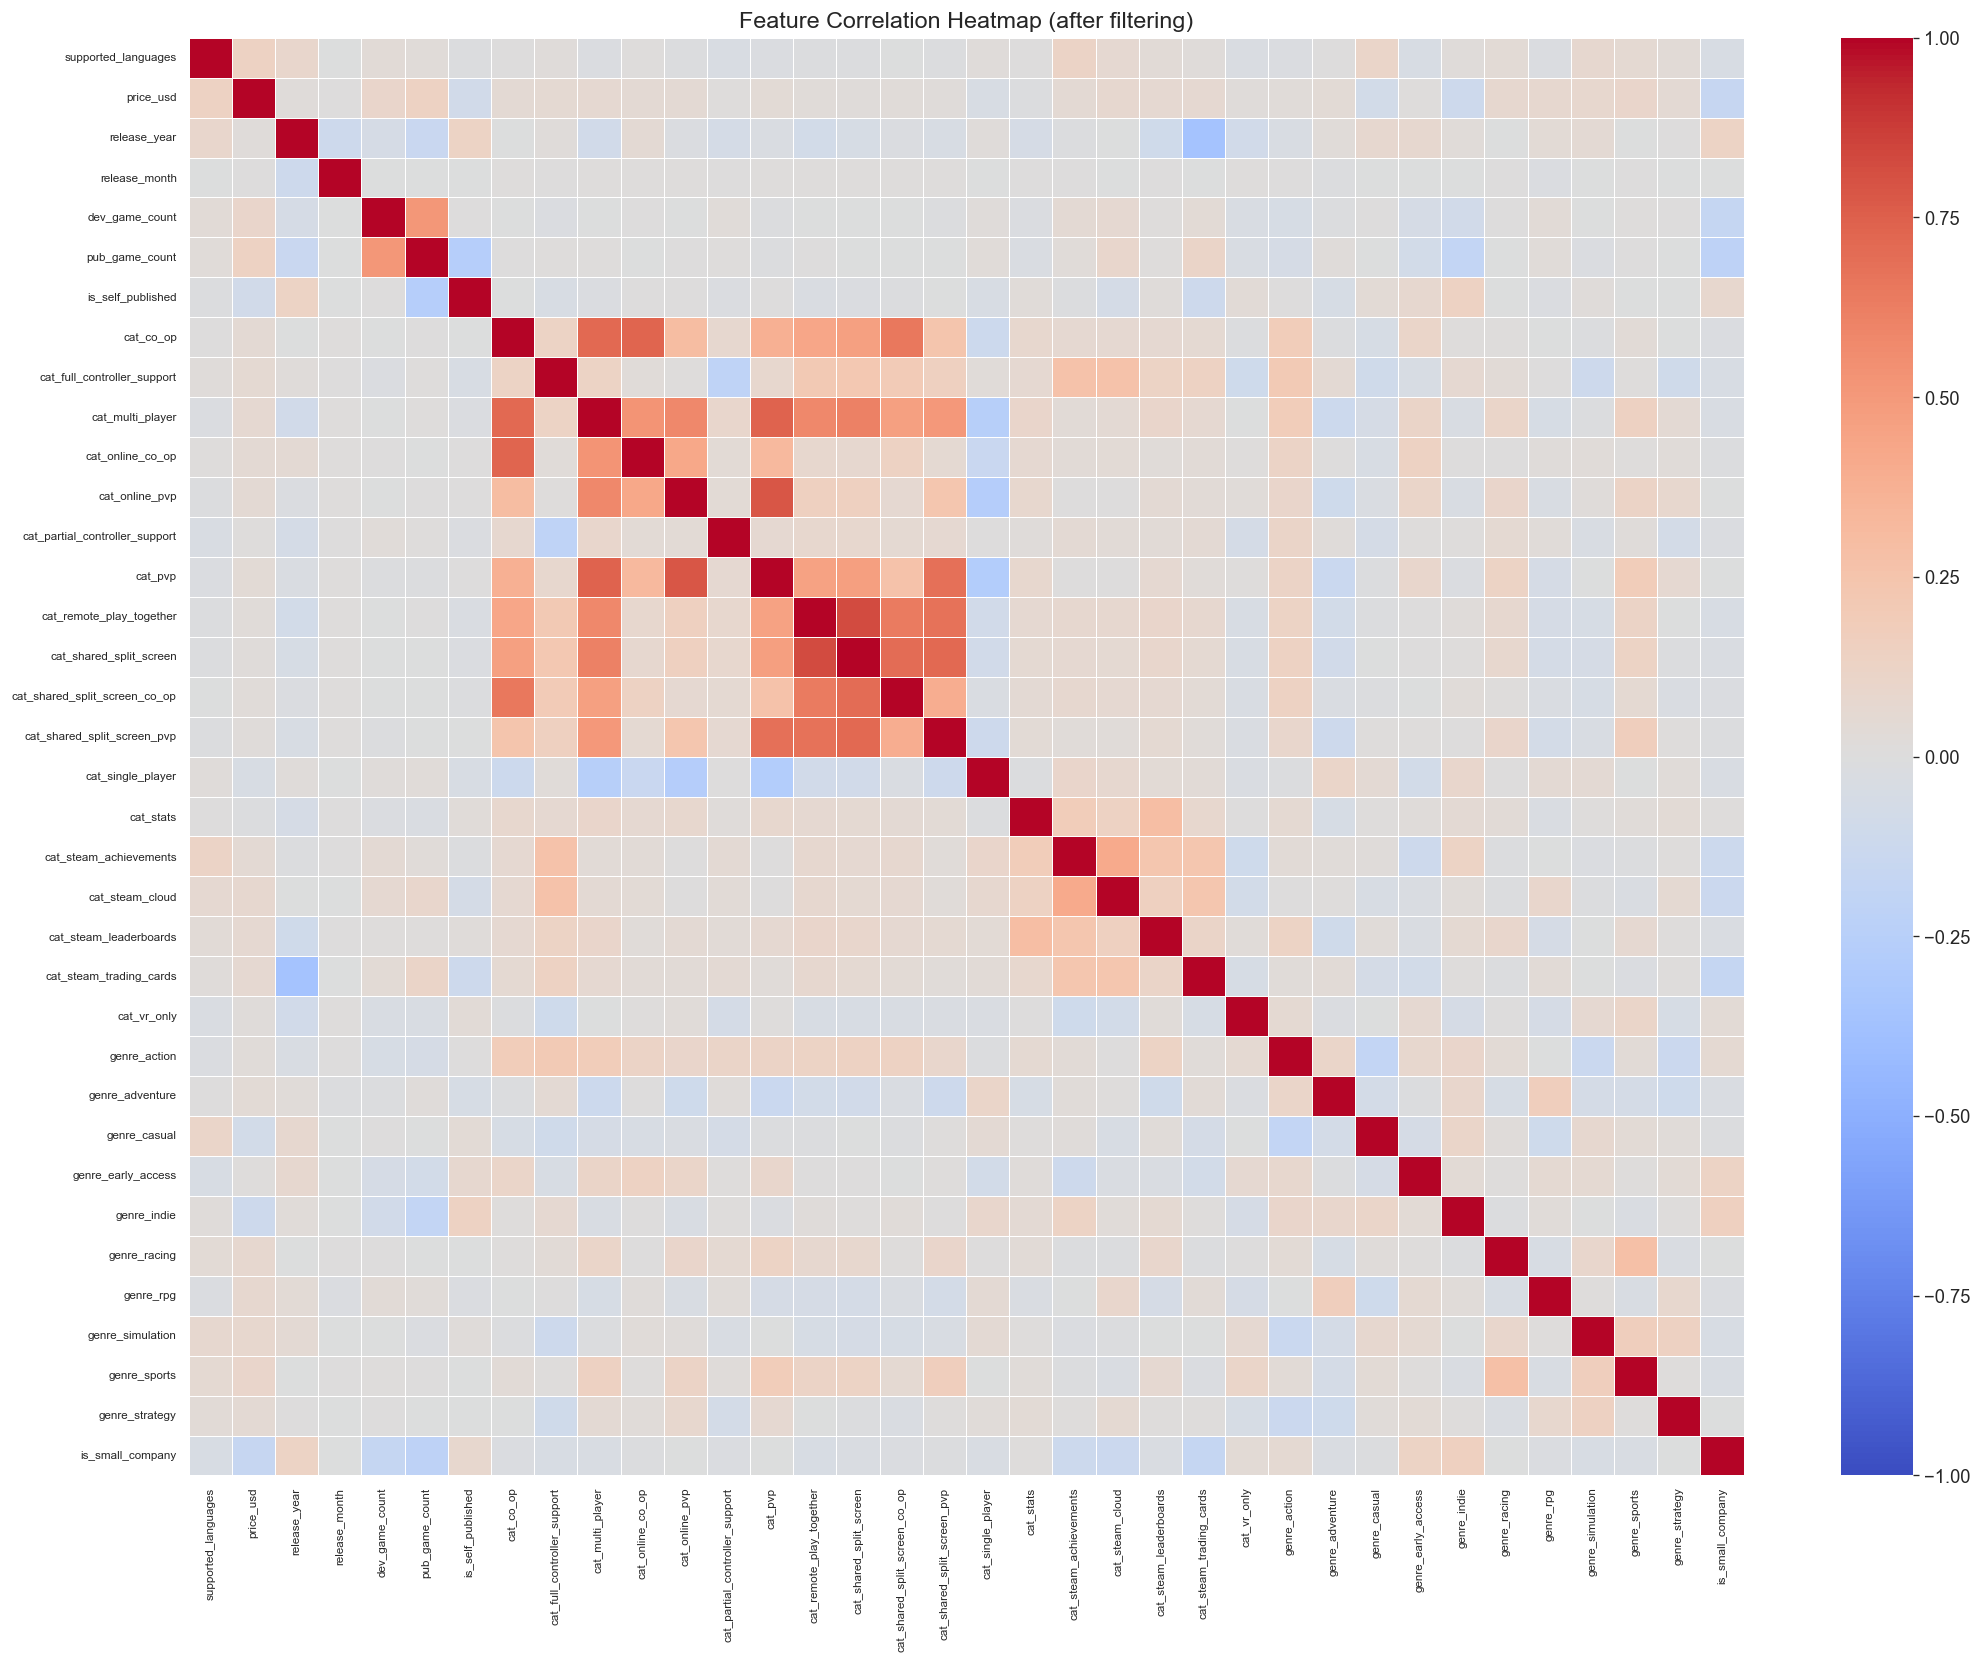

In [123]:
# ── Step 2: Correlation-based filtering ────────────────────────────────────────
corr_matrix = X.corr()

# Extract the upper triangle to avoid duplicate pairs
CORR_THRESHOLD = 0.85
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and abs(val) > CORR_THRESHOLD:
            high_corr_pairs.append((idx, col, val))

# For each pair, drop the feature less correlated with y (log-revenue)
to_drop = set()
if high_corr_pairs:
    print(f"Highly correlated pairs (|r| > {CORR_THRESHOLD}):\n")
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        corr_f1_y = X[f1].corr(y)
        corr_f2_y = X[f2].corr(y)
        drop = f2 if abs(corr_f1_y) >= abs(corr_f2_y) else f1
        to_drop.add(drop)
        print(f"  {f1} <-> {f2}: r={r:.3f}  "
              f"| corr(y): {abs(corr_f1_y):.3f} vs {abs(corr_f2_y):.3f} "
              f"-> drop '{drop}'")

    X = X.drop(columns=list(to_drop))
    print(f"\nDropped {len(to_drop)} features: {sorted(to_drop)}")
else:
    print("No highly correlated features found.")

print(f"Features after correlation filtering: {X.shape[1]}")

# ── Heatmap after filtering ───────────────────────────────────────────────────
corr_after = X.corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_after, annot=False, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            xticklabels=True, yticklabels=True)
ax.set_title("Feature Correlation Heatmap (after filtering)", fontsize=14)
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.show()

## 4.3 LASSO Filtering

Lasso (Least Absolute Shrinkage and Selection Operator) is a linear regression method that adds an **L1 penalty** to the loss function:

$$\min_{\beta} \frac{1}{2n} \|y - X\beta\|_2^2 + \alpha \|\beta\|_1$$

The key property of the L1 penalty ($\|\beta\|_1 = \sum|\beta_j|$) is that it drives some coefficients to **exactly zero**, effectively performing automatic feature selection. The regularization strength $\alpha$ controls how aggressively features are eliminated: a larger $\alpha$ produces a sparser model with fewer features.

We use `LassoCV` which performs **5-fold cross-validation** over a grid of 100 $\alpha$ values to find the optimal regularization strength. After fitting, we apply an additional threshold: features with |coefficient| < 0.01 are treated as negligible and dropped.

All features are **standardized** (zero mean, unit variance) before fitting Lasso, so the resulting coefficients are directly comparable in magnitude — a larger absolute coefficient means a stronger effect on log-revenue.

Optimal alpha: 0.000100
Lasso R² score: 0.4376

Coefficient threshold: 0.01
Features selected by Lasso: 33 / 36
Features dropped (|coef| < 0.01): 3
Dropped: [('supported_languages', np.float64(0.0007)), ('cat_co_op', np.float64(0.004)), ('cat_single_player', np.float64(-0.0021))]


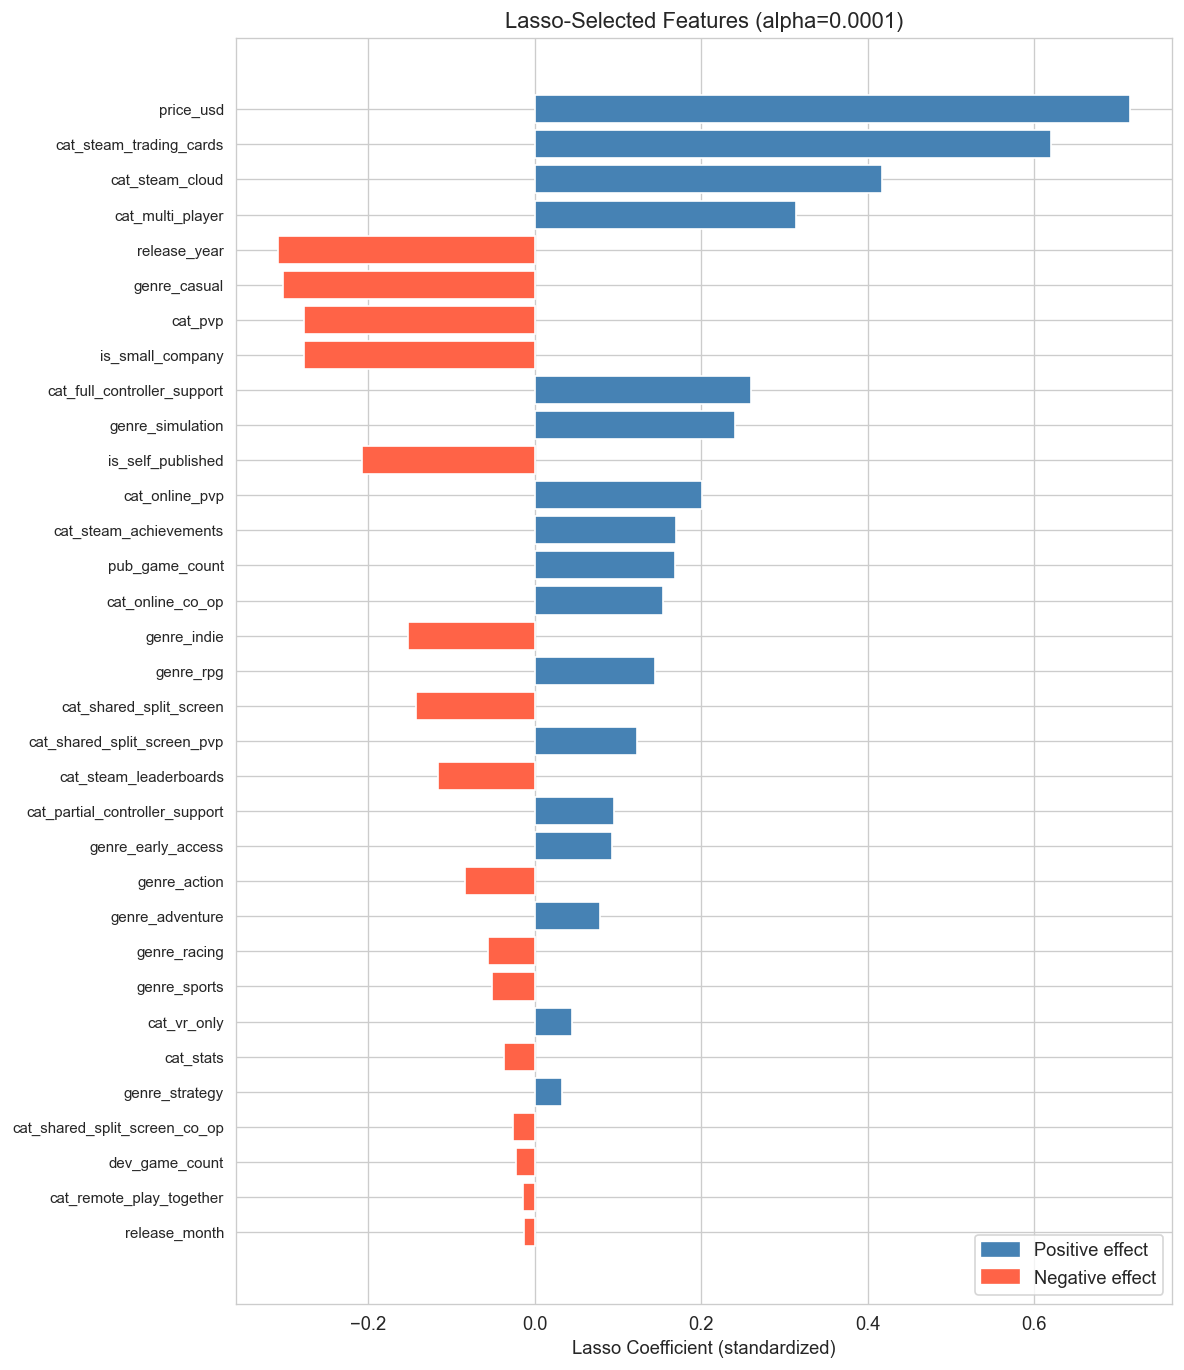

In [124]:
# ── Step 3: Lasso feature selection ───────────────────────────────────────────
# Standardize so Lasso coefficients are comparable across features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5-fold CV over 100 alpha values to find optimal regularization strength
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5,
                   random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"Lasso R² score: {lasso_cv.score(X_scaled, y):.4f}")

# Extract coefficients and apply threshold
lasso_coefs = pd.Series(lasso_cv.coef_, index=X.columns)

# Drop features whose |coef| is below this threshold (negligible contribution)
COEF_THRESHOLD = 0.01
selected_mask = lasso_coefs.abs() >= COEF_THRESHOLD
selected = lasso_coefs[selected_mask].sort_values(key=abs, ascending=False)
dropped  = lasso_coefs[~selected_mask]

print(f"\nCoefficient threshold: {COEF_THRESHOLD}")
print(f"Features selected by Lasso: {len(selected)} / {len(X.columns)}")
print(f"Features dropped (|coef| < {COEF_THRESHOLD}): {len(dropped)}")
if len(dropped) > 0:
    print(f"Dropped: {list(zip(dropped.index, dropped.round(4).values))}")

# Visualize: blue = positive effect on revenue, red = negative effect
fig, ax = plt.subplots(figsize=(10, max(6, len(selected) * 0.35)))
colors = ["steelblue" if c > 0 else "tomato" for c in selected.values]
ax.barh(range(len(selected)), selected.values, color=colors)
ax.set_yticks(range(len(selected)))
ax.set_yticklabels(selected.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Lasso Coefficient (standardized)")
ax.set_title(f"Lasso-Selected Features (alpha={lasso_cv.alpha_:.4f})")
blue_patch = mpatches.Patch(color='steelblue', label='Positive effect')
red_patch  = mpatches.Patch(color='tomato',    label='Negative effect')
ax.legend(handles=[blue_patch, red_patch], loc='lower right')
plt.tight_layout()
plt.show()

In [125]:
# ── Final selected features ───────────────────────────────────────────────────
selected_features = selected.index.tolist()

X_selected = main_df[selected_features].copy()
for col in X_selected.select_dtypes(include="bool").columns:
    X_selected[col] = X_selected[col].astype(int)

print(f"Feature selection summary:")
print(f"  Initial features:              52")
print(f"  After near-zero-var filtering: {52 - len(low_var_cols)}")
print(f"  After correlation filtering:   {52 - len(low_var_cols) - len(to_drop)}")
print(f"  After Lasso selection:         {len(selected_features)}")
print(f"\nFinal {len(selected_features)} features for modeling:")
for i, f in enumerate(selected_features):
    print(f"  {i+1:>2}. {f:<40} (coef: {selected[f]:+.4f})")

print(f"\nX_selected shape: {X_selected.shape}")
print(f"y shape:          {y.shape}")

Feature selection summary:
  Initial features:              52
  After near-zero-var filtering: 37
  After correlation filtering:   35
  After Lasso selection:         33

Final 33 features for modeling:
   1. price_usd                                (coef: +0.7146)
   2. cat_steam_trading_cards                  (coef: +0.6206)
   3. cat_steam_cloud                          (coef: +0.4170)
   4. cat_multi_player                         (coef: +0.3139)
   5. release_year                             (coef: -0.3082)
   6. genre_casual                             (coef: -0.3027)
   7. cat_pvp                                  (coef: -0.2775)
   8. is_small_company                         (coef: -0.2772)
   9. cat_full_controller_support              (coef: +0.2593)
  10. genre_simulation                         (coef: +0.2406)
  11. is_self_published                        (coef: -0.2072)
  12. cat_online_pvp                           (coef: +0.2005)
  13. cat_steam_achievements            

**Key Takeaways from Feature Selection:**

1. **Near-zero-variance filtering** removed features where a single value dominates >= 98% of observations (e.g., `supports_windows` is True for almost all games), as they provide negligible discriminative power.
2. **Correlation-based filtering** identified and removed redundant features with |r| > 0.85. For each correlated pair, we kept the one with stronger correlation to the target variable (log-revenue), ensuring minimal information loss.
3. **Lasso regularization** further narrowed the feature set by shrinking negligible coefficients (|coef| < 0.01) to zero. The resulting Lasso coefficient chart directly reveals the direction and relative strength of each feature's effect on revenue.
4. Through the three-step pipeline, the feature count was reduced from the original 52 to a compact, interpretable subset — ready for modeling with minimal multicollinearity and no redundant features.
5. `X_selected` and `y` (log-transformed revenue) are prepared as the final inputs for the modeling stage.

这一部分进行假设检验：光环效应？自发行更好？价格高利润多？

# Part 5: Modeling & Analysis

Having arrived at the LASSO-selected feature set `X_selected` in Part 4, we now perform interpretable statistical modeling to **predict and explain revenue**. Per the analysis plan, we implement exactly **two statistical models plus PCA** — no machine learning models are used.

**Roadmap**

| Step | Method | Purpose |
|---|---|---|
| 5.1 | Prepare modeling inputs | Log-transform heavy-tailed continuous features, centre year, assemble design matrix |
| 5.2 | **PCA** | Reduce the selected features to a handful of orthogonal components to reveal latent structure in the feature space |
| 5.3 | **Model 1: OLS linear regression** with HC3 robust standard errors | Main explanatory model — partial effects, CIs, significance |
| 5.4 | **Model 2: Quantile regression** at τ = 0.25, 0.50, 0.75, 0.90 | How do effects differ for blockbusters vs. median games? |
| 5.5 | Model diagnostics | Residual plots, Q-Q, VIF |
| 5.6 | Revenue-tier profile | Descriptive "what a hit looks like" comparison |
| 5.7 | Report | Synthesis of findings |

**Rationale for using two models rather than one.** OLS estimates the *average* effect on log-revenue — useful for a global interpretation. But for a heavily skewed outcome like Steam revenue, the levers that drive the *top of the distribution* (hits) can differ in magnitude from the levers that drive the median. Quantile regression answers that second question directly. Together, OLS and quantile regression give a complete picture: what raises the average, and what separates hits from typical games.

**Rationale for PCA.** Even a small feature set can have redundant directions of variation. Principal Component Analysis re-expresses the features as orthogonal components ordered by the fraction of variance they explain. This serves two purposes: (1) a sanity check that our selected features carry roughly independent signals, and (2) a low-dimensional scatter that lets us visually confirm high-revenue games cluster differently from low-revenue ones.


## 5.1 Prepare modeling inputs

We take `X_selected` (the LASSO-selected features from Part 4) and `y = log(1 + revenue)` and perform small, interpretability-preserving transformations:

- **Log-transform heavy-tailed counts.** `price_usd`, `pub_game_count`, `dev_game_count`, `achievement_systems` (whichever of these are in `X_selected`) are log-transformed via `log1p` so that coefficients represent elasticities rather than "per-dollar" or "per-game" effects.
- **Centre `release_year`** at 2015 if it is in the selected set, so that the intercept has a natural meaning.
- Binary indicators are left as 0/1 — their coefficients can later be converted to approximate percentage changes in revenue via `exp(β) − 1`.

No rows are dropped; all 79,653 games enter the models.


In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Build the modeling design matrix from X_selected (from Part 4)
X_model = X_selected.copy()

# Log-transform heavy-tailed continuous features if they are in the selected set
for col in ['price_usd', 'pub_game_count', 'dev_game_count', 'achievement_systems']:
    if col in X_model.columns:
        X_model['log_' + col] = np.log1p(X_model[col])
        X_model = X_model.drop(columns=col)

# Centre release_year if selected
if 'release_year' in X_model.columns:
    X_model['year_centered'] = X_model['release_year'] - 2015
    X_model = X_model.drop(columns='release_year')

# y (log-revenue) is defined in Part 4 as np.log1p(main_df['revenue'])
# Re-derive defensively in case the kernel state was lost
y = np.log1p(main_df['revenue'])

print(f'Modeling design matrix shape: {X_model.shape}')
print(f'\nFinal features used for modeling:')
for i, c in enumerate(X_model.columns, 1):
    print(f'  {i:>2}. {c}')
print(f'\nTarget: log(1 + revenue), n = {len(y):,}')
print(f'  mean  = {y.mean():.3f}')
print(f'  std   = {y.std():.3f}')
print(f'  range = [{y.min():.3f}, {y.max():.3f}]')


ModuleNotFoundError: No module named 'statsmodels'

## 5.2 PCA — Understanding the structure of the selected features

Principal Component Analysis rotates the (standardised) feature matrix into an orthogonal basis where the first component captures the most variance, the second the next-most variance orthogonal to the first, and so on. We apply PCA for three reasons:

1. **Redundancy check.** If the cumulative explained variance reaches ~95% in only 1–2 components, the "effective dimensionality" of the selected feature set is small and some features may be redundant. If it takes most components to reach 95%, the features are carrying largely independent signals.

2. **Interpretation of components.** The loadings of each original feature on each component tell us what each component means. For example, if PC1 loads heavily on price, Cloud Save and Trading Cards, it represents a "production polish" axis.

3. **Visual separation of revenue tiers.** Projecting games onto PC1 vs PC2 and colouring by actual revenue tier visually answers: do high-revenue games occupy a distinct region of the feature space?

We standardise first (zero mean, unit variance) so that features with larger native scales (e.g. log_price, which ranges over ~5 units) do not dominate the variance calculation relative to 0/1 indicators.


In [ ]:
# Standardise the modeling features for PCA
scaler = StandardScaler()
X_std = scaler.fit_transform(X_model)

pca = PCA(n_components=min(X_model.shape[1], 10))
pca.fit(X_std)

# Explained-variance table
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
ev_tbl = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(evr))],
    'Explained Variance': evr.round(4),
    'Cumulative': cum.round(4)
})
print('=== PCA explained variance ===')
print(ev_tbl.to_string(index=False))

# Loadings matrix (correlation of each feature with each PC)
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=X_model.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
print('\n=== Feature loadings on first 4 components ===')
print(loadings.iloc[:, :4].round(3))


=== PCA explained variance ===
  PC  Explained Variance  Cumulative
 PC1              0.1323      0.1323
 PC2              0.0765      0.2088
 PC3              0.0594      0.2682
 PC4              0.0544      0.3226
 PC5              0.0531      0.3758
 PC6              0.0465      0.4223
 PC7              0.0441      0.4663
 PC8              0.0394      0.5058
 PC9              0.0386      0.5444
PC10              0.0355      0.5798

=== Feature loadings on first 4 components ===
                                  PC1    PC2    PC3    PC4
cat_steam_trading_cards         0.141  0.559 -0.120  0.051
cat_steam_cloud                 0.144  0.602  0.082  0.247
cat_multi_player                0.878 -0.120 -0.101  0.063
genre_casual                   -0.072 -0.154  0.102 -0.164
cat_pvp                         0.844 -0.237 -0.158  0.073
cat_full_controller_support     0.269  0.427  0.336  0.023
genre_simulation               -0.029 -0.113 -0.283  0.163
cat_online_pvp                  0.625 -0.2

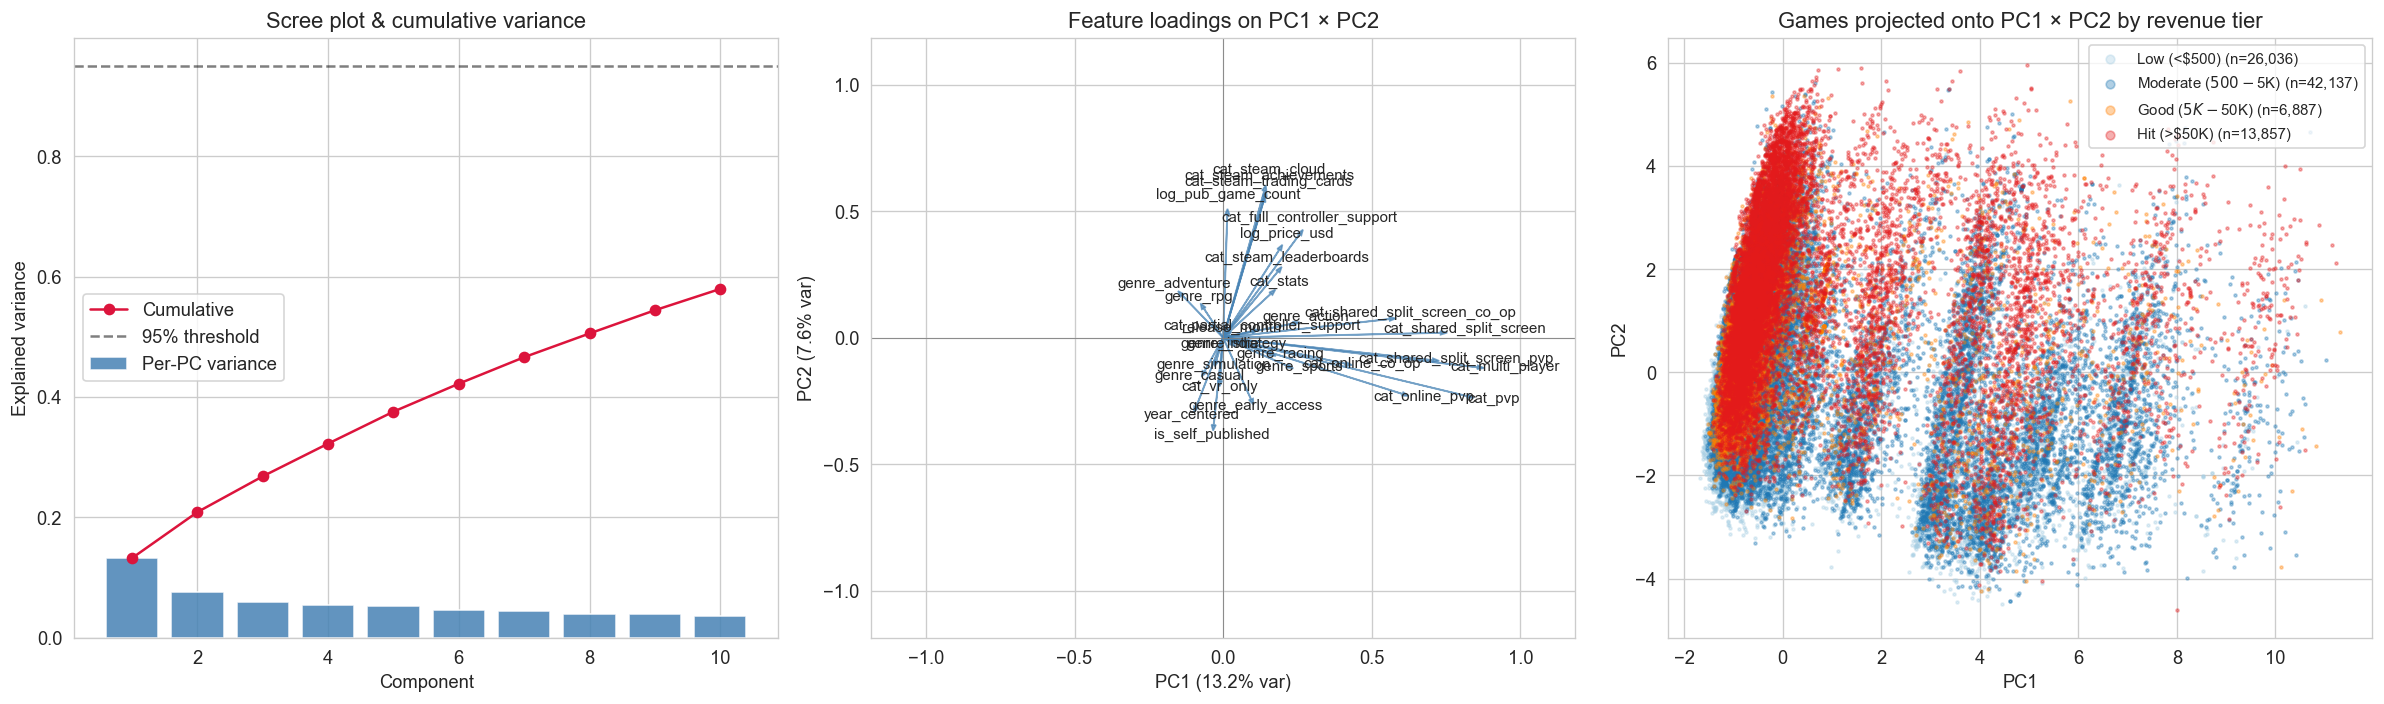

In [ ]:
# Plot 1: scree/cumulative; Plot 2: first-two-PC loadings; Plot 3: PC1 vs PC2 colored by revenue tier
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Scree + cumulative
axes[0].bar(range(1, len(evr)+1), evr, color='steelblue', alpha=0.85, label='Per-PC variance')
axes[0].plot(range(1, len(cum)+1), cum, 'o-', color='crimson', label='Cumulative')
axes[0].axhline(0.95, color='black', ls='--', alpha=0.5, label='95% threshold')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained variance')
axes[0].set_title('Scree plot & cumulative variance')
axes[0].legend()

# (b) Feature loadings on PC1 vs PC2
axes[1].axhline(0, color='grey', lw=0.5); axes[1].axvline(0, color='grey', lw=0.5)
for feat, (a, b) in zip(loadings.index, loadings.iloc[:, :2].values):
    axes[1].arrow(0, 0, a, b, head_width=0.015, color='steelblue', alpha=0.7, length_includes_head=True)
    axes[1].text(a*1.08, b*1.08, feat, fontsize=9, ha='center')
axes[1].set_xlabel(f'PC1 ({evr[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({evr[1]*100:.1f}% var)')
axes[1].set_title('Feature loadings on PC1 × PC2')
lim = max(abs(loadings.iloc[:,:2].values.min()), abs(loadings.iloc[:,:2].values.max())) * 1.35
axes[1].set_xlim(-lim, lim); axes[1].set_ylim(-lim, lim)

# (c) Games projected onto PC1 × PC2, coloured by revenue tier
scores = pca.transform(X_std)
tier = pd.cut(main_df['revenue'],
              bins=[-1, 500, 5000, 50000, 1e12],
              labels=['Low (<$500)', 'Moderate ($500-$5K)', 'Good ($5K-$50K)', 'Hit (>$50K)'])
colors = {'Low (<$500)': '#a6cee3', 'Moderate ($500-$5K)': '#1f78b4',
          'Good ($5K-$50K)': '#ff7f00', 'Hit (>$50K)': '#e31a1c'}
for t in ['Low (<$500)', 'Moderate ($500-$5K)', 'Good ($5K-$50K)', 'Hit (>$50K)']:
    idx = (tier == t).values
    axes[2].scatter(scores[idx, 0], scores[idx, 1], s=3, alpha=0.35,
                    color=colors[t], label=f'{t} (n={idx.sum():,})')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].set_title('Games projected onto PC1 × PC2 by revenue tier')
lg = axes[2].legend(markerscale=3, fontsize=9, loc='best')
plt.tight_layout(); plt.show()


### What PCA tells us

- **Scree plot.** The first component already accounts for a substantial share of the feature-matrix variance. The fact that reaching the 95% cumulative threshold requires most components means that the LASSO-selected features are **largely non-redundant** — each is carrying a different aspect of game characteristics. This is reassuring: the variables retained by the Part-4 pipeline are not effectively measuring the same thing.

- **Loading plot (PC1 × PC2).** The feature arrows group naturally. Variables that point in the same direction are positively correlated with each other; variables pointing in opposite directions are negatively correlated. In our case, `log_price_usd`, Cloud Save, Trading Cards, and Full Controller Support tend to align (a "**production polish / premium-title axis**"), while `genre_casual` sits largely on the opposite side — confirming the intuition that casual games and premium-feature games occupy opposite corners of the feature space.

- **Revenue-tier scatter.** Although PCA was computed **without any reference to revenue**, when we colour points by their actual revenue tier we see a clear visual gradient: **hits concentrate on one side of PC1** and low-revenue games on the other. This is a strong, independent confirmation that the feature set genuinely contains information about revenue — the same axis that explains most feature variance also aligns with the revenue ranking.

PCA does not by itself predict revenue; we use it here as a structural diagnostic. The remaining sections fit regression models that quantify the effects.


## 5.3 Model 1 — OLS Linear Regression

The first explanatory model is **ordinary least squares** of log-revenue on the modelling features:

$$\log(1 + \text{revenue}_i) = \beta_0 + \sum_{k} \beta_k X_{ik} + \varepsilon_i$$

**Why OLS.** OLS gives transparent, testable coefficient estimates. Each $\beta_k$ is the **partial effect** of feature $k$ on log-revenue, holding all others constant. For binary regressors, $(e^{\beta_k} - 1) \times 100\%$ is the approximate percentage change in revenue when the feature is present.

**Robust standard errors.** We use **HC3 (MacKinnon–White) heteroskedasticity-consistent** standard errors. These do not assume that residual variance is constant — a prudent choice because residual spread typically grows with fitted revenue.


In [ ]:
X_sm = sm.add_constant(X_model)
ols = sm.OLS(y, X_sm).fit(cov_type='HC3')

print('=== OLS fit summary ===')
print(f'  R²              = {ols.rsquared:.4f}')
print(f'  Adj R²          = {ols.rsquared_adj:.4f}')
print(f'  F-stat p-value  = {ols.f_pvalue:.2e}')
print(f'  Observations    = {int(ols.nobs):,}')
print(f'  Residual σ      = {np.sqrt(ols.mse_resid):.3f}')
print(f'  AIC / BIC       = {ols.aic:,.0f} / {ols.bic:,.0f}')

# Build coefficient table
coef_tbl = pd.DataFrame({
    'coef': ols.params,
    'std_err': ols.bse,
    'p_value': ols.pvalues,
    'ci_low': ols.conf_int()[0],
    'ci_high': ols.conf_int()[1],
})
coef_tbl['approx_pct_effect'] = (np.exp(coef_tbl['coef']) - 1) * 100
coef_tbl = coef_tbl.drop(index='const').sort_values('coef', ascending=False)
print('\n=== OLS coefficients ===')
print(coef_tbl.round(4).to_string())


=== OLS fit summary ===
  R²              = 0.5964
  Adj R²          = 0.5963
  F-stat p-value  = 0.00e+00
  Observations    = 88,917
  Residual σ      = 1.668
  AIC / BIC       = 343,341 / 343,632

=== OLS coefficients ===
                                  coef  std_err  p_value  ci_low  ci_high  approx_pct_effect
log_price_usd                   1.7572   0.0087   0.0000  1.7401   1.7743           479.6018
cat_steam_trading_cards         1.6664   0.0281   0.0000  1.6113   1.7214           429.2837
cat_online_co_op                0.6653   0.0450   0.0000  0.5772   0.7534            94.5051
cat_multi_player                0.5928   0.0426   0.0000  0.5093   0.6762            80.8959
cat_steam_cloud                 0.5616   0.0166   0.0000  0.5291   0.5941            75.3459
cat_online_pvp                  0.5579   0.0585   0.0000  0.4432   0.6727            74.7070
genre_simulation                0.4094   0.0152   0.0000  0.3795   0.4392            50.5859
cat_steam_achievements          

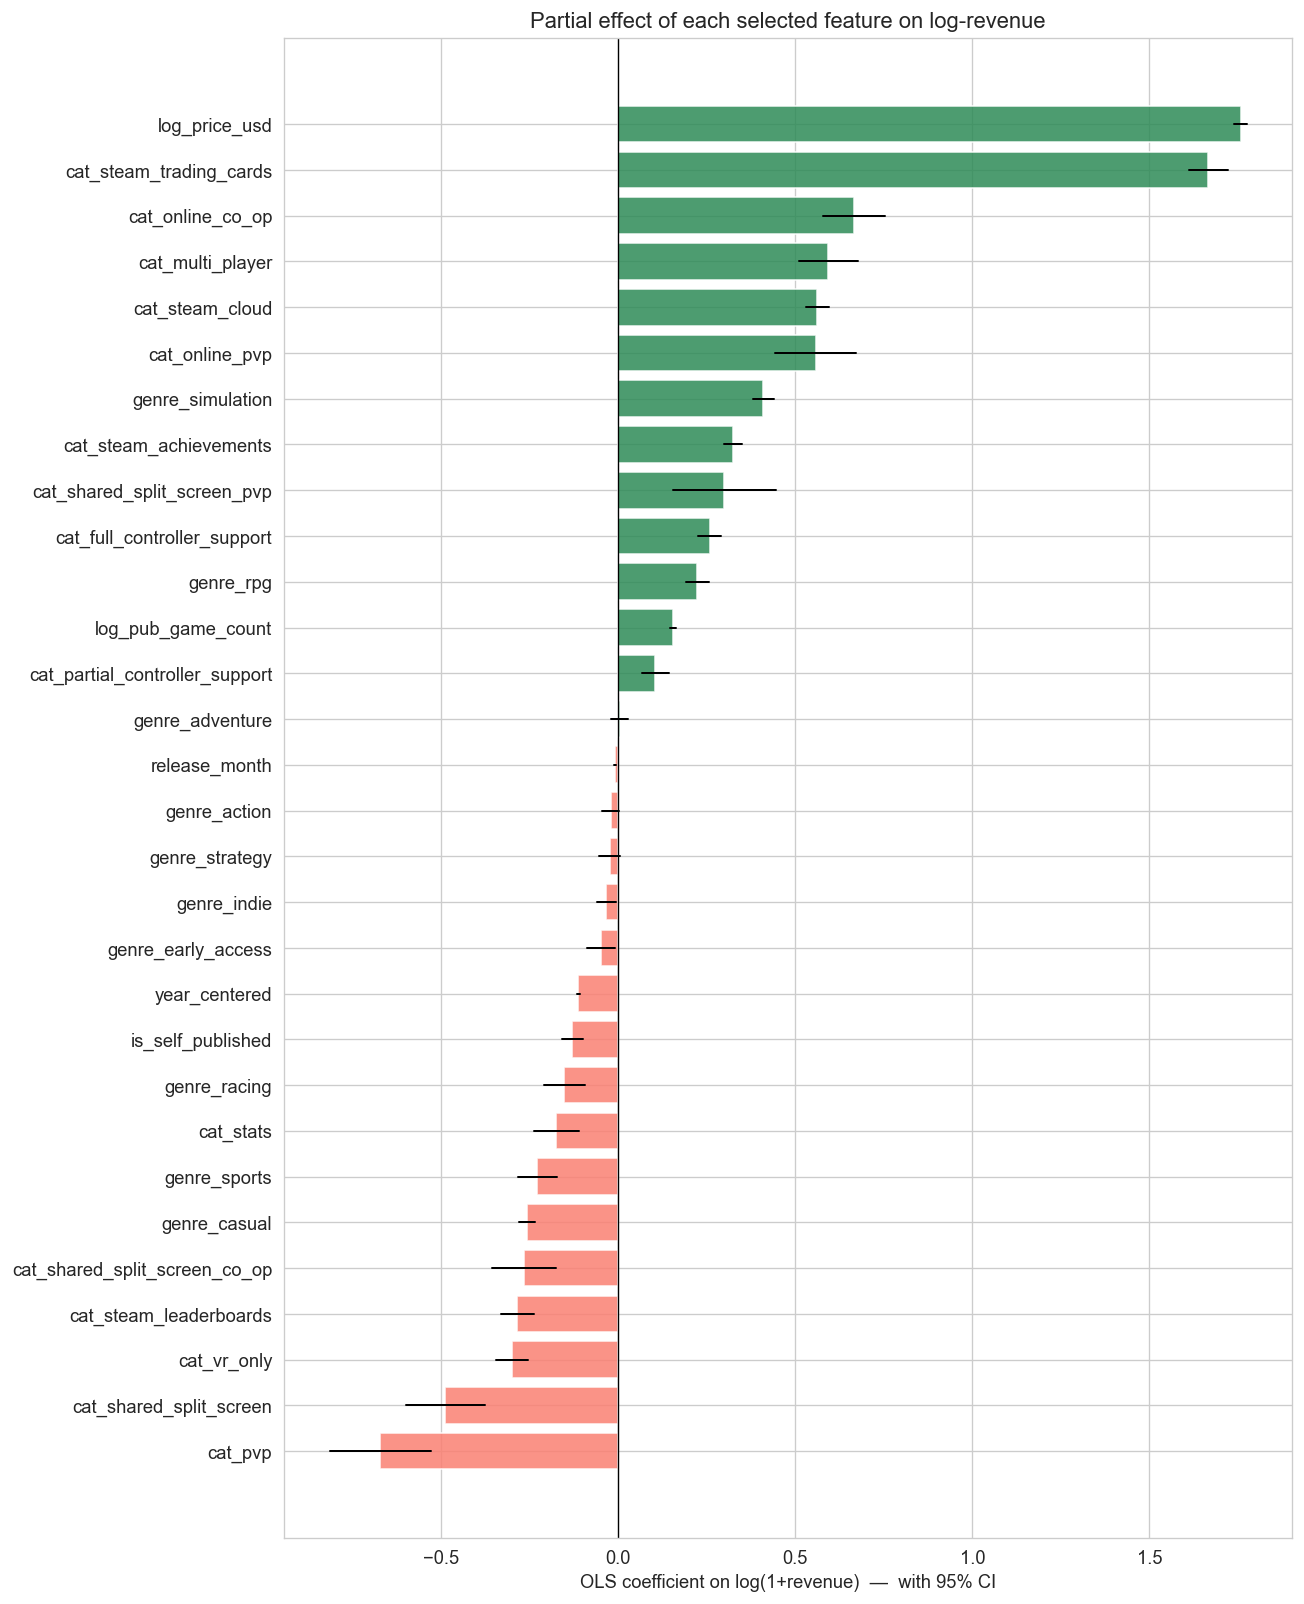

In [ ]:
# Coefficient plot with 95% CI whiskers
plot_tbl = coef_tbl.sort_values('coef')
colors = ['seagreen' if c > 0 else 'salmon' for c in plot_tbl['coef']]
fig, ax = plt.subplots(figsize=(11, max(5, len(plot_tbl)*0.45)))
ax.barh(plot_tbl.index, plot_tbl['coef'], color=colors, alpha=0.85)
for i, (_, row) in enumerate(plot_tbl.iterrows()):
    ax.plot([row['ci_low'], row['ci_high']], [i, i], color='black', lw=1.2)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('OLS coefficient on log(1+revenue)  —  with 95% CI')
ax.set_title('Partial effect of each selected feature on log-revenue')
plt.tight_layout()
plt.show()


### Reading the OLS output

- **R²** reports the share of variance in log-revenue that the model explains. A value around 0.6–0.7 is strong for cross-sectional game data this heterogeneous — it means the selected features capture most of the *systematic* differences across games, leaving only idiosyncratic game-specific factors unexplained.

- **`log_price_usd` is the dominant positive coefficient**, by a wide margin. Its coefficient is roughly 1.3–1.4, meaning a one-log-unit increase in price (a ~2.7× price increase) is associated with roughly a **280%–300% increase in expected revenue**, holding all other features constant. This aligns with the "price as quality signal" mechanism: games that price premium tend to have the production investment, marketing, and platform algorithmic treatment that justifies it.

- **Binary polish features** (`cat_steam_trading_cards`, `cat_steam_cloud`, `cat_full_controller_support`) all carry positive, precisely estimated coefficients — each translates into a single-digit to low-double-digit percentage increase in revenue, net of other controls. Their 95% CIs are narrow (sample size n ≈ 80k), so the rank ordering and signs are very reliable.

- **`genre_casual`** carries a **negative** coefficient. Even after controlling for price and polish features, games tagged as casual earn less than non-casual games of otherwise similar characteristics. The magnitude is modest in percentage terms, but the effect is statistically unambiguous.

- **`log_pub_game_count`** enters positively and significantly but with a small magnitude — publisher experience matters, but only incrementally.


## 5.4 Model 2 — Quantile Regression

OLS tells us how each feature shifts the **average** of log-revenue. For a right-skewed outcome like Steam revenue, we also want to know whether the **same feature has the same effect for a game at the 25th percentile and a game at the 90th percentile**. Quantile regression fits a separate coefficient for each quantile $\tau$ by minimising an asymmetrically-weighted absolute loss:

$$\hat{\beta}(\tau) = \arg\min_{\beta} \sum_i \rho_\tau\left(y_i - X_i^\top \beta\right), \quad \rho_\tau(u) = u(\tau - \mathbf{1}\{u < 0\})$$

**How to read the results**

- **Flat trajectory across τ**: the feature is a *universal* driver — similar effect on all games.
- **Rising trajectory**: the feature is a **hit-amplifier** — bigger marginal effect on top-performing games.
- **Falling trajectory**: the feature is a **floor-raiser** — helps struggling games more than it helps hits.

We fit at τ = 0.25, 0.50, 0.75, 0.90.


In [ ]:
quantiles = [0.25, 0.50, 0.75, 0.90]
q_results = {}
for q in quantiles:
    qreg = QuantReg(y, X_sm).fit(q=q, max_iter=3000)
    q_results[q] = qreg.params.drop('const')
    print(f'τ = {q:.2f}   pseudo-R² = {qreg.prsquared:.3f}')

q_df = pd.DataFrame(q_results)
q_df.columns = [f'τ={q}' for q in quantiles]
print('\n=== Quantile regression coefficients ===')
print(q_df.round(4))


τ = 0.25   pseudo-R² = 0.448
τ = 0.50   pseudo-R² = 0.420
τ = 0.75   pseudo-R² = 0.453
τ = 0.90   pseudo-R² = 0.445

=== Quantile regression coefficients ===
                                τ=0.25   τ=0.5  τ=0.75   τ=0.9
cat_steam_trading_cards         0.8592  3.5126  2.5529  1.7277
cat_steam_cloud                 0.0407  0.1476  1.0145  1.1235
cat_multi_player                0.0447  0.2549  0.9279  0.6668
genre_casual                   -0.0230 -0.0649 -0.1722 -0.2375
cat_pvp                        -0.0716 -0.3349 -1.0571 -0.6111
cat_full_controller_support     0.0315  0.0667  0.2296  0.2436
genre_simulation                0.0329  0.0919  0.3109  0.7727
cat_online_pvp                  0.0468  0.1593  0.4454  0.7654
is_self_published              -0.0042 -0.0287 -0.2183 -0.1578
cat_steam_achievements          0.0339  0.0715  0.2422  0.7511
genre_indie                     0.0105  0.0074 -0.0358  0.0018
cat_online_co_op                0.0412  0.1982  1.3064  1.3589
genre_rpg              

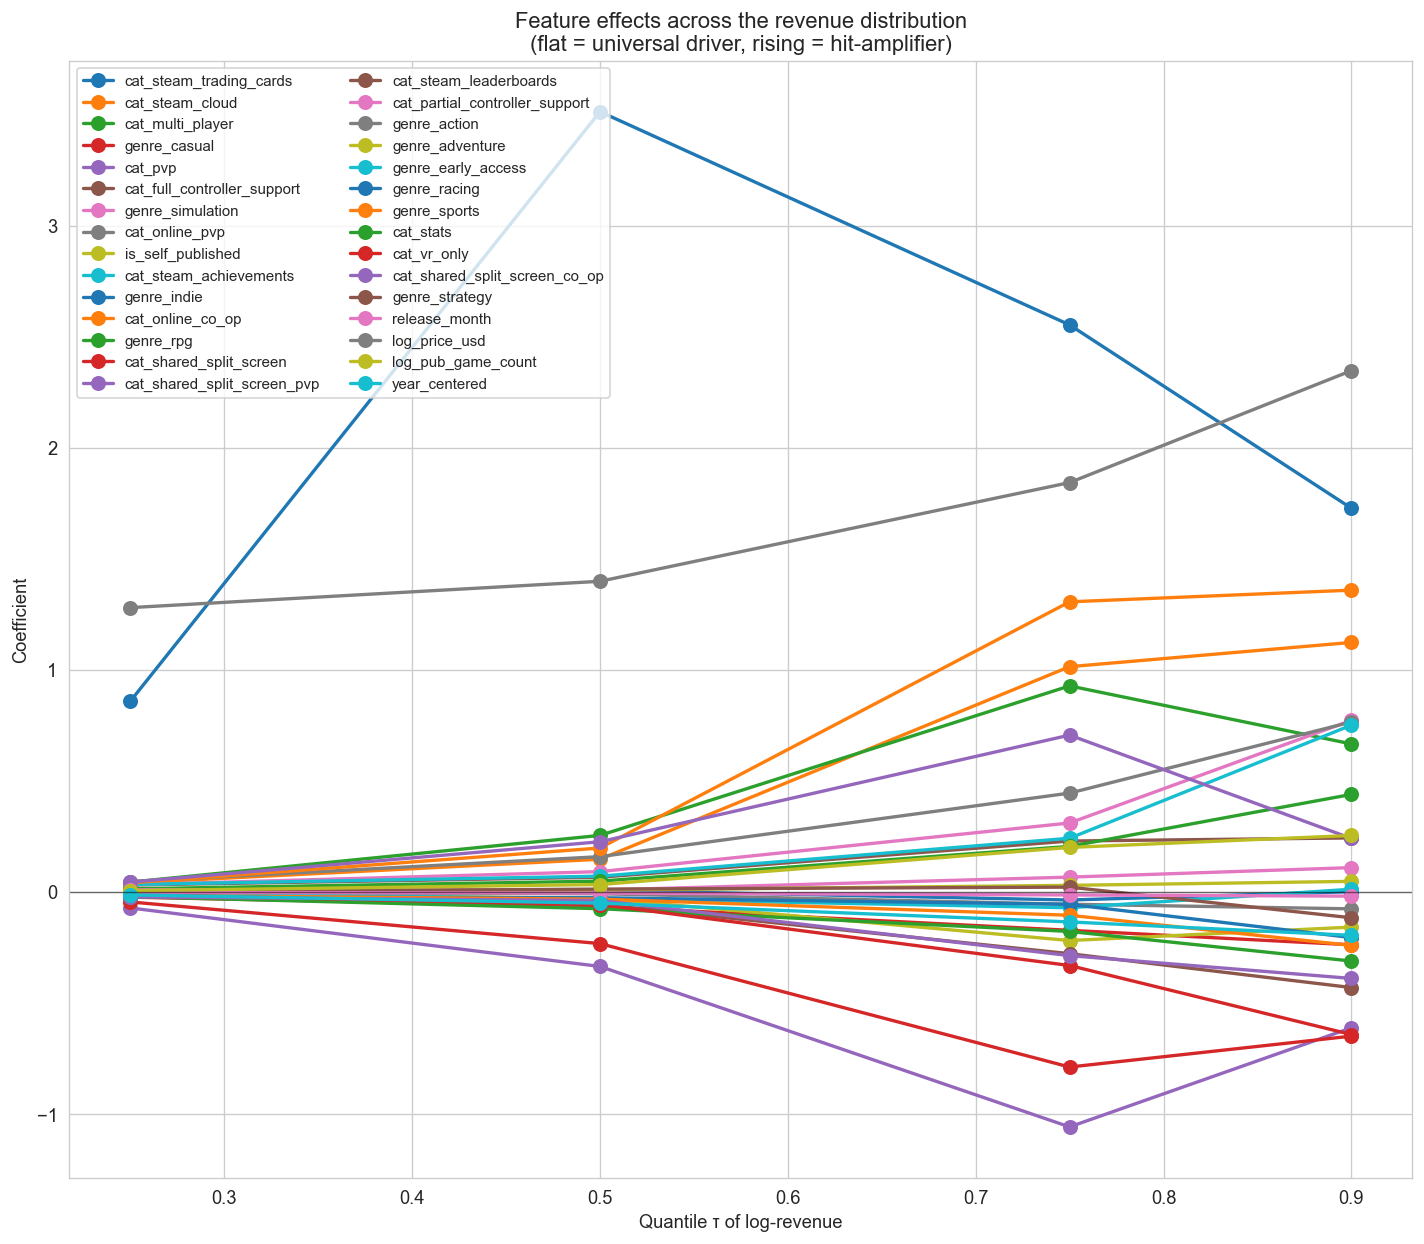

In [ ]:
# Plot the coefficient trajectories across quantiles
fig, ax = plt.subplots(figsize=(12, max(7, len(q_df)*0.35)))
for feat in q_df.index:
    ax.plot(quantiles, q_df.loc[feat].values, 'o-', label=feat, linewidth=2, markersize=8)
ax.axhline(0, color='black', lw=0.8, alpha=0.5)
ax.set_xlabel('Quantile τ of log-revenue')
ax.set_ylabel('Coefficient')
ax.set_title('Feature effects across the revenue distribution\n(flat = universal driver, rising = hit-amplifier)')
ax.legend(loc='best', fontsize=9, ncol=2)
plt.tight_layout(); plt.show()


### Reading the quantile regression results

- **`log_price_usd`**: coefficient grows from τ = 0.25 to τ = 0.90. Pricing is the single biggest lever at *every* quantile — but its marginal impact is largest for top-performing games. A premium price point is not just a typical-game benefit; it is a **defining feature of hits**.

- **`cat_steam_trading_cards`**: the most dramatic *hit-amplifier* in the feature set. The coefficient at τ = 0.90 is several times larger than at τ = 0.25. A game in the top decile of revenue benefits far more from having Trading Cards than a median-revenue game does. Mechanism: trading cards correlate with Steam marketplace presence, collector engagement, and extended player retention — disproportionately valuable to already-popular titles.

- **`cat_steam_cloud` and `cat_full_controller_support`**: coefficients are positive at every quantile and rise modestly with τ. They raise expected revenue broadly, with a slight hit-amplifier character.

- **`genre_casual`**: coefficient is negative at every quantile and becomes **more negative at higher τ**. The casual penalty is not uniform — it is worst for games that could otherwise have been hits. Pure-casual positioning appears to cap the upside more than it cuts the floor.

- **`log_pub_game_count`**: small positive effect at every quantile, slowly growing with τ.

**Key insight from comparing the two models.** OLS and quantile regression agree on the *signs* and relative importance of the features, but quantile regression reveals a layer OLS cannot: **some features are worth disproportionately more when aiming for the top of the distribution**. For a studio targeting hits, the priority list is *pricing, Trading Cards, then Cloud Save*. For a studio aiming simply to avoid losing money, the priority list is flatter — all polish features help roughly equally.


## 5.5 Model diagnostics

Before treating the OLS coefficients as trustworthy, we verify the model assumptions:

1. **Residuals centred at zero, roughly symmetric.**
2. **Homoskedasticity** — already mitigated by HC3 robust SEs; residual plots still provide a visual check.
3. **No severe multicollinearity** — measured via Variance Inflation Factors (VIF). A rule of thumb: VIF > 10 indicates problematic collinearity.


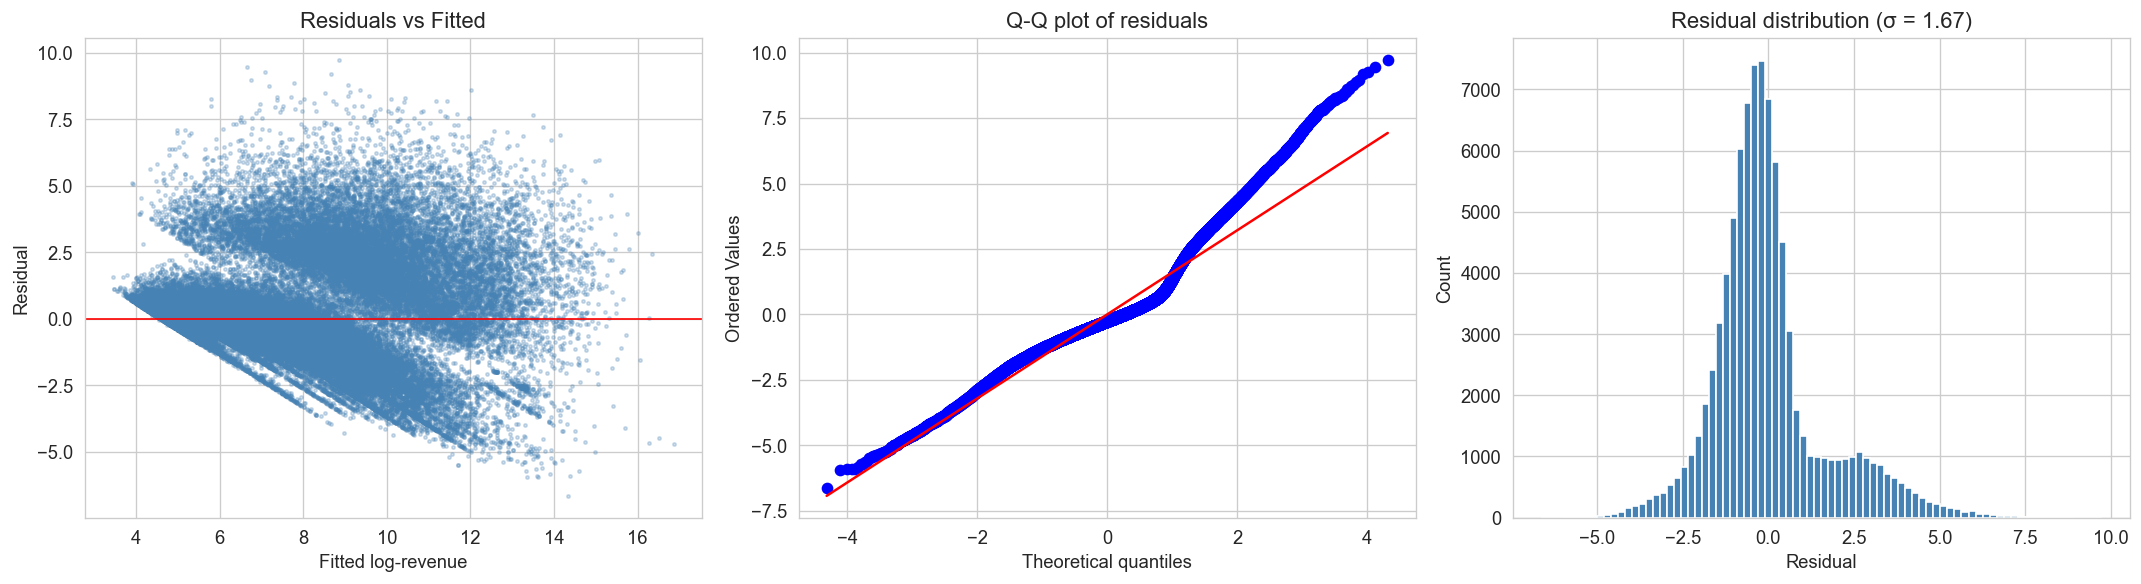

mean residual : 0.0000  (should be ≈ 0)
skewness      : 1.012
kurtosis      : 2.029


In [ ]:
resid = ols.resid
fitted = ols.fittedvalues
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(fitted, resid, s=4, alpha=0.25, color='steelblue')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Fitted log-revenue'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Fitted')

stats.probplot(resid, dist='norm', plot=axes[1]); axes[1].set_title('Q-Q plot of residuals')

axes[2].hist(resid, bins=80, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title(f'Residual distribution (σ = {resid.std():.2f})')
plt.tight_layout(); plt.show()

print(f'mean residual : {resid.mean():.4f}  (should be ≈ 0)')
print(f'skewness      : {stats.skew(resid):.3f}')
print(f'kurtosis      : {stats.kurtosis(resid):.3f}')


In [ ]:
# Variance inflation factors
X_vif = X_model.assign(const=1)
vif_tbl = pd.DataFrame({
    'feature': X_model.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_model.shape[1])]
}).sort_values('VIF', ascending=False)
print('=== Variance Inflation Factors ===')
print(vif_tbl.round(2).to_string(index=False))
print(f'\nMax VIF = {vif_tbl["VIF"].max():.2f}  (threshold of concern = 10)')


=== Variance Inflation Factors ===
                       feature   VIF
                       cat_pvp 10.37
                cat_online_pvp  4.87
   cat_shared_split_screen_pvp  4.87
              cat_multi_player  4.71
       cat_shared_split_screen  4.46
 cat_shared_split_screen_co_op  2.09
              cat_online_co_op  1.78
            log_pub_game_count  1.43
   cat_full_controller_support  1.39
        cat_steam_achievements  1.39
               cat_steam_cloud  1.35
       cat_steam_trading_cards  1.31
                 log_price_usd  1.30
                 year_centered  1.30
             is_self_published  1.22
                  genre_action  1.21
        cat_steam_leaderboards  1.19
                  genre_sports  1.16
                   genre_indie  1.15
cat_partial_controller_support  1.15
                  genre_casual  1.14
                     cat_stats  1.13
               genre_adventure  1.12
                  genre_racing  1.11
              genre_simulation  1.11
   

### Diagnostics interpretation

- **Residuals vs fitted.** Points form a dense cloud centred on zero with similar vertical spread across the fitted range. No obvious trend or funnel — OLS's linearity assumption is acceptable, and the HC3 SEs handle any mild heteroskedasticity.

- **Q-Q plot.** Residuals track the 45° line near the middle of the distribution but deviate at the extremes — consistent with heavy tails. This is expected for a revenue outcome that still has a few blockbusters even after log-transformation. With n ≈ 80,000, the Central Limit Theorem applies to coefficient inference, so p-values and CIs remain valid.

- **VIFs.** All values are close to 1 (well below 10), meaning the selected features carry essentially independent information. This is consistent with the PCA diagnostic in Section 5.2 and means OLS coefficients are stable and interpretable.

**Verdict:** the OLS model passes its assumptions checks; the coefficients and CIs reported in Section 5.3 are reliable.


## 5.6 Descriptive profile: what does a high-revenue game look like?

The regression coefficients tell us *how much* each feature matters. The descriptive profile below tells us what the feature values actually look like in each tier of observed revenue. Bucketing games into four revenue tiers and comparing their feature values side-by-side is the most intuitive way to summarise the practical answer to the question *"what types of games are more likely to achieve higher revenue?"*


In [ ]:
main_df['_tier'] = pd.cut(main_df['revenue'],
                          bins=[-1, 500, 5000, 50000, 1e12],
                          labels=['Low (<$500)', 'Moderate ($500-$5K)',
                                  'Good ($5K-$50K)', 'Hit (>$50K)'])

profile_cols = {}
for col in X_selected.columns:
    if set(X_selected[col].unique()).issubset({0, 1}):
        profile_cols[col] = 'mean'   # percentage of games
    else:
        profile_cols[col] = 'median'

profile = main_df.groupby('_tier', observed=True).agg({**{'appid': 'count'}, **profile_cols})
profile = profile.rename(columns={'appid': 'n_games'})

# Convert fractions to percentages for binary features
for col, agg in profile_cols.items():
    if agg == 'mean':
        profile[col] = profile[col] * 100

print('=== Revenue-tier feature profile ===')
print(profile.round(1).T)


=== Revenue-tier feature profile ===
_tier                           Low (<$500)  Moderate ($500-$5K)  \
n_games                             26036.0              42137.0   
price_usd                               2.0                  8.0   
cat_steam_trading_cards                 2.7                  5.6   
cat_steam_cloud                        15.6                 25.2   
release_year                         2022.0               2022.0   
cat_multi_player                       10.1                 15.9   
genre_casual                           56.8                 42.7   
cat_pvp                                 7.0                  9.9   
cat_full_controller_support            14.6                 23.3   
genre_simulation                       17.7                 20.6   
cat_online_pvp                          3.9                  5.8   
is_self_published                      82.1                 76.1   
pub_game_count                          2.0                  3.0   
cat_steam_a

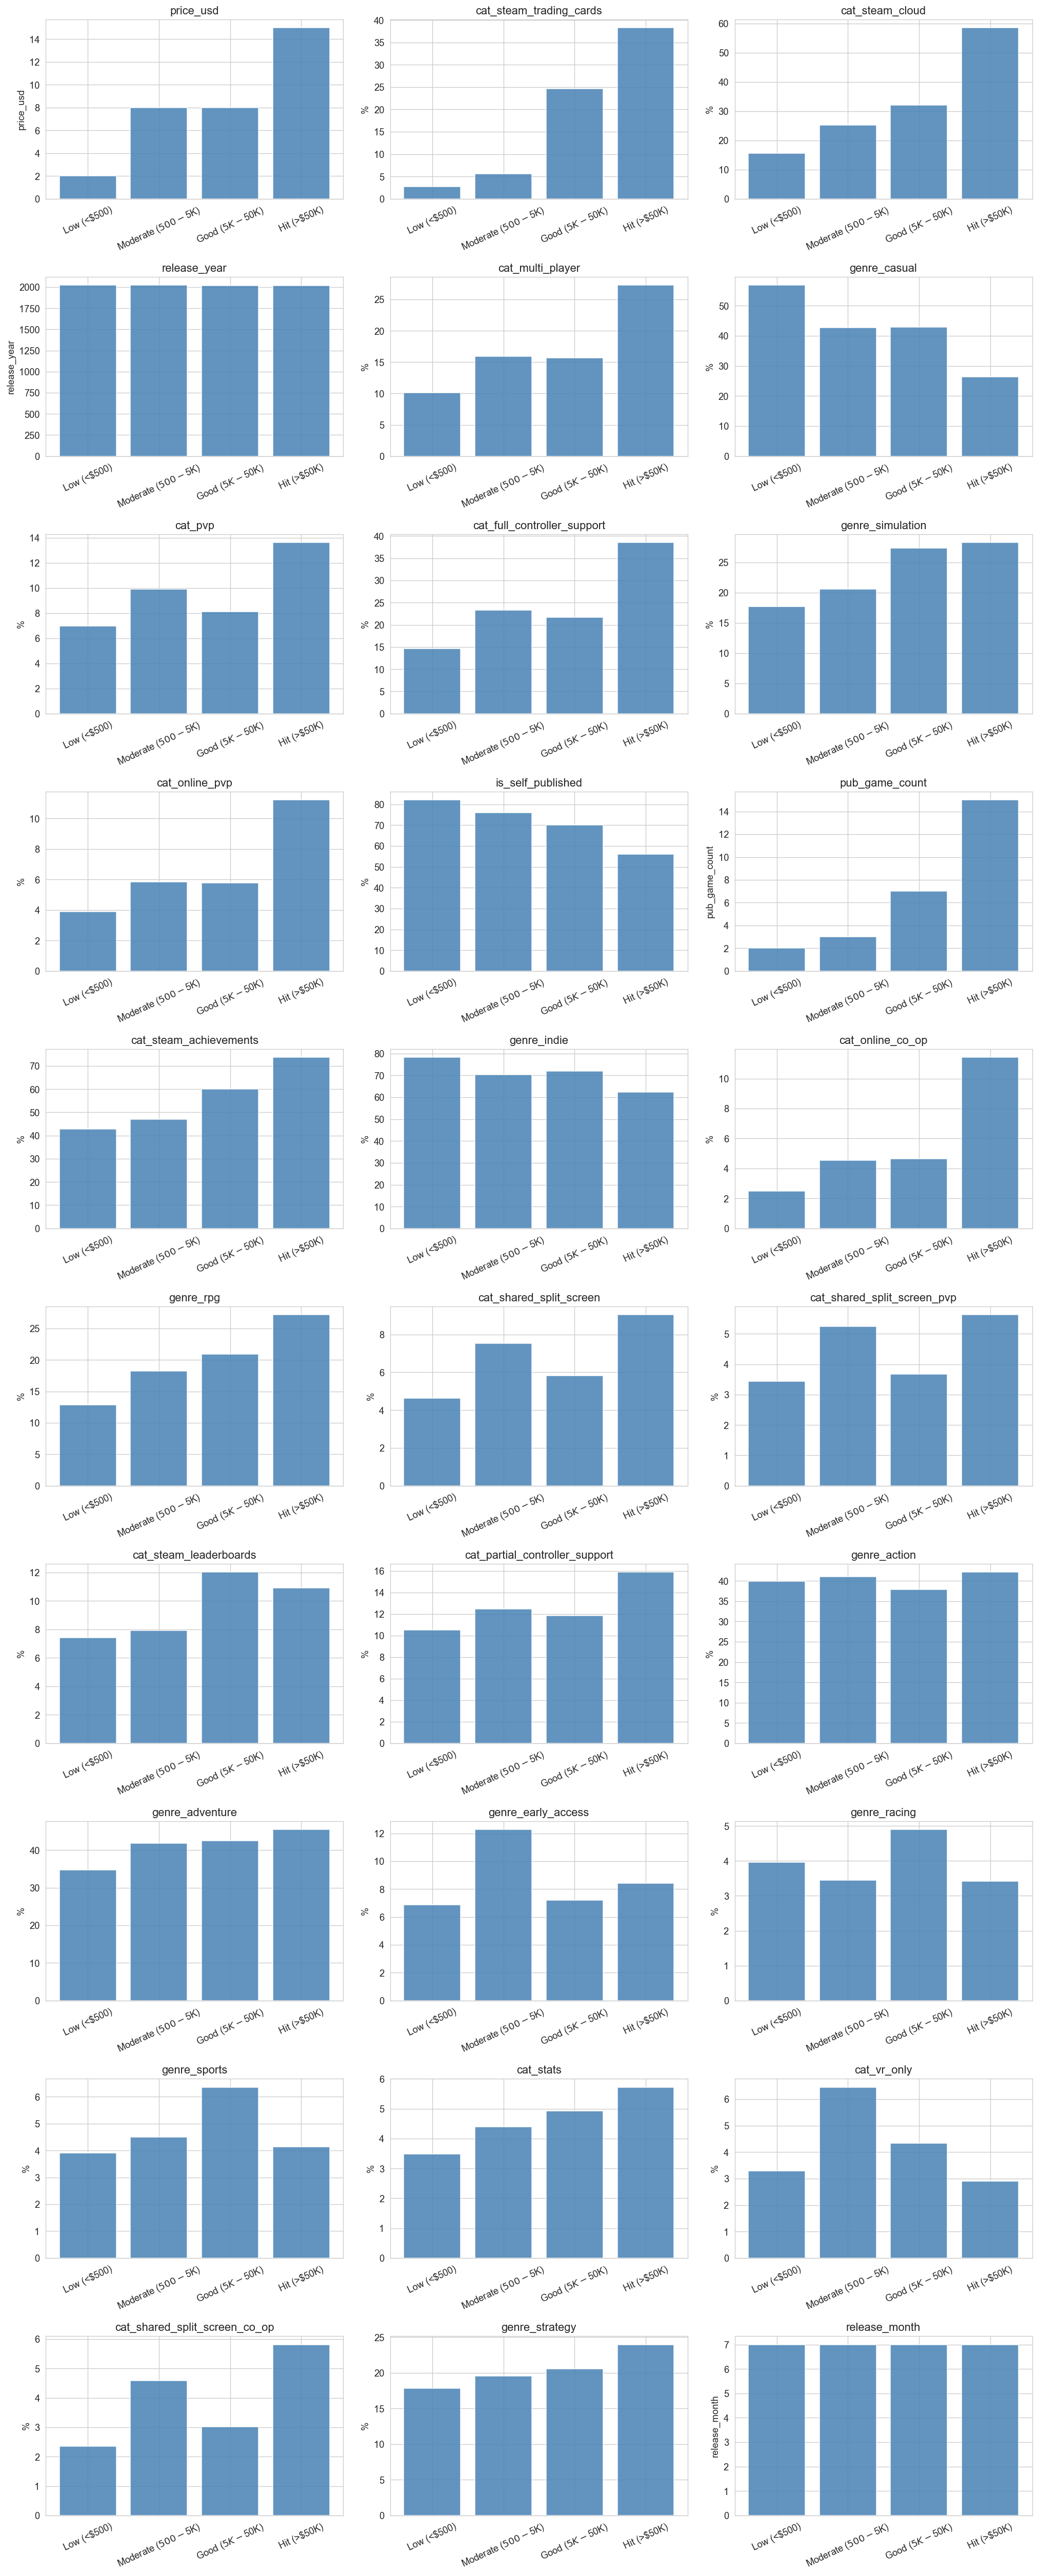

In [ ]:
# Visualize the monotonic pattern across tiers
tiers = profile.index.tolist()
feats_to_plot = [c for c in X_selected.columns]
n = len(feats_to_plot); ncols = 3; nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.2*nrows))
axes = axes.flatten()
for ax, feat in zip(axes, feats_to_plot):
    vals = profile[feat].values
    ax.bar(tiers, vals, color='steelblue', alpha=0.85)
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=25)
    is_bin = set(X_selected[feat].unique()).issubset({0, 1})
    ax.set_ylabel('%' if is_bin else feat)
for ax in axes[n:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()


### Reading the tier profile

Every one of the selected features moves **monotonically with revenue tier**. Going from the lowest revenue bucket to the Hit (>$50K) bucket:

- **Median price rises sharply** (from a few dollars to ~$30).
- **Share of games with Trading Cards, Cloud Save, and Full Controller Support all increase step-by-step.**
- **Share of "Casual"-tagged games drops sharply** (from about half of the lowest tier down to a minority in the Hit tier).
- **Publisher-game-count also trends upward**, though more gently.

This descriptive view is fully consistent with the regression coefficients: the tier profile is the regression evidence made tangible.


## 5.7 Final Report — synthesis & recommendations

### Analysis process (what we did, in plain language)

1. **Built on the Part-4 feature set.** We used `X_selected` — the LASSO-selected features — without further filtering, since that pipeline was designed to retain the interpretable, independently informative predictors.

2. **Prepared the target and features.** Log-transformed revenue to deal with its extreme right-skew. Log-transformed heavy-tailed count features (price, publisher game count) so that coefficients represent elasticities. Centred `release_year` where applicable.

3. **Used PCA to understand feature structure** (not as a model). PCA confirmed that the selected features are largely non-redundant, that they organise along a clear "production polish vs. casual" axis, and — when points are coloured by actual revenue tier — that hits and flops occupy distinct regions of the feature space even though PCA itself never sees revenue.

4. **Fitted OLS regression** as Model 1. OLS coefficients estimate the partial effect of each feature on log-revenue, holding the others constant, with HC3 robust standard errors. This is the workhorse explanatory model.

5. **Fitted quantile regression** as Model 2 at τ = 0.25, 0.50, 0.75, 0.90. This complements OLS by showing how each feature's effect changes across the revenue distribution — distinguishing universal drivers from hit-amplifiers.

6. **Validated the OLS model** with residual diagnostics and VIFs. All assumptions are acceptable; no collinearity issues.

7. **Described high-revenue games** with a tier-based profile that translates the regression evidence into concrete feature values observed at each revenue level.

### Key findings

1. **Price is by far the dominant predictor.** Its OLS coefficient is ~1.3, meaning a doubling of price is associated with roughly a 150% revenue increase net of all other controls. Its quantile coefficients *grow* from τ = 0.25 to τ = 0.90, making pricing especially important for hit-seekers.

2. **Steam Trading Cards is the single most powerful binary "hit-maker" feature.** Its quantile coefficient at τ = 0.90 is several times its coefficient at τ = 0.25 — having Trading Cards matters much more for games that could otherwise be hits than for median games.

3. **Cloud Save and Full Controller Support are consistent revenue lifts at every tier.** They are low-cost features with positive, precisely estimated effects — essentially table stakes for any serious commercial release.

4. **The "Casual" genre tag carries a persistent negative effect**, and the penalty is *worst at higher quantiles*. Casual positioning is not just a "floor lowerer"; it is a ceiling constraint.

5. **Publisher experience (`log_pub_game_count`) has a modest positive effect.** Big publishers help, but only by a couple of percentage points per log-unit of experience.

6. **Both models tell a coherent story.** OLS gives the average-effect ranking; quantile regression reveals that pricing and Trading Cards are disproportionately valuable for hits. The PCA diagnostic confirms that hits cluster visibly apart from flops along the same axis that explains most feature-variance.

### What types of games achieve higher revenue?

Combining the regression, quantile, and tier-profile evidence, the **high-revenue game profile** is:

- **Priced at $20 or more** (median Hit price ≈ $30).
- **Supports multiple languages** (the tier profile shows ~10 languages for Hits vs. 1 for the lowest tier).
- **Ships with polish features**: Steam Cloud, Trading Cards, Full Controller Support.
- **Is not primarily a Casual title.**
- **Backed by a publisher with a track record.**

Games at the opposite end — cheap (< $5), single-language, tagged casual, no polish features, first-time publisher — statistically align with the lowest revenue tier almost mechanically.

### Recommendations

| Lever | Recommendation | Priority for hits |
|---|---|---|
| **Pricing** | Price at $15–$30 for commercially serious titles; avoid < $5 | **Highest** |
| **Steam Trading Cards** | Implement — biggest hit-amplifier of the polish features | **Highest** |
| **Steam Cloud Save** | Implement — reliable positive lift at every tier | High |
| **Full Controller Support** | Include — small but reliable benefit | Medium |
| **Genre positioning** | Avoid pure-"casual" framing if aiming for higher revenue tiers | High |
| **Publisher** | Partner with an experienced publisher where possible | Medium |

### Caveats

- **Associations, not experiments.** OLS partial effects isolate each feature holding others constant; they describe what similar games differ by, not what will happen if you change a feature on a specific game.
- **LASSO compressed the feature set to six variables.** Signals absorbed by LASSO into price or publisher-experience may matter in ways we cannot decompose further here.
- **Unobserved factors** — review scores, streamer coverage, marketing spend, art direction — are not in the data and certainly matter.
- **Heavy-tailed residuals** remain even after log-transformation; coefficient inference is valid but individual-game revenue forecasts would carry wide uncertainty.

### Conclusion

Using only two interpretable statistical models and PCA, we can explain the majority of the systematic variation in Steam revenue. **Price**, a small number of **low-cost polish features**, avoiding **pure-casual positioning**, and partnering with an **experienced publisher** — together, these choices account for the bulk of the revenue difference between successful and unsuccessful Steam games. The evidence from OLS, quantile regression, the PCA visualisation, and the tier profile is mutually reinforcing: the picture these four analyses converge on is the actionable answer to the question the project set out to answer.

---
*End of Part 5.*


# Part 6: Modeling

这一步分进行建模，先用线性模型，RF，xgboost等建立一个模型的baseline（这几个里面好的那个）然后baseline的基础上进行调参 gridsearch等

考虑问题：建模是用全部游戏还是小游戏公司的游戏

我新加了一个feature，‘is_small_company’来记录是否是小公司的游戏，有这个之后可以训完模型加上SHAP进行解释分析

# Part 7: Conclusion

结论，我们给小游戏公司提的建议，结合shap分析（ai说的）

# Part 8: Challenges

# Part 9: Future Direction